# ABP Modulo 5

## Lección 1: — Análisis exploratorio de datos 
### Objetivo: Comprender el propósito del EDA y diferenciarlo del análisis inciial 

In [341]:
from datetime import datetime, timedelta # trabaja con fechas y calcula diferencias de tiempo
import numpy as np # Calculos matematicos y manejo de arrays
import pandas as pd # Cargar, limpiar y transformar datos (DataFrames)
import statsmodels.api as sm # Modelos estadísticos, regresión lineal
import warnings # Manejo de advertencias (warnings)
import matplotlib.pyplot as plt # Visualización de datos
import matplotlib.ticker as mticker # Formateo de ejes en gráficos
import seaborn as sns # Visualización de datos estadísticos (gráficos más atractivos)
from sklearn.metrics import mean_squared_error, mean_absolute_error # Métricas de evaluación de modelos
warnings.filterwarnings('ignore') # Ignorar advertencias para mantener la salida limpia

pd.set_option('display.max_columns', None) # Mostrar todas las columnas al imprimir DataFrames
pd.set_option('display.float_format', '{:.2f}'.format) # Formato de números flotantes (2 decimales) al imprimir DataFrames

## Generación de Dataset 

In [342]:
# Rangos de fechas
fecha_inicio_2025  = datetime(2025, 1, 1)
fecha_fin_2025     = datetime(2025, 12, 31)
fecha_inicio_2026  = datetime(2026, 1, 1)
fecha_fin_2026     = datetime(2026, 2,28)   # Fecha de corte del análisis, febrero 2026

# 2% de fechas con error (fuera de rango)
fecha_error_inicio = fecha_inicio_2026 + timedelta(days=90)
fecha_error_fin    = fecha_inicio_2026 + timedelta(days=100)

In [343]:
def generar_fecha_registro():

    r = np.random.random() # Número aleatorio entre 0 y 1 para decidir el tipo de fecha a generar
    if r < 0.02:                          # 2% fechas incorrectas para hacer limpieza
        dias = (fecha_error_fin - fecha_error_inicio).days
        return fecha_error_inicio + timedelta(days=np.random.randint(0, dias)) 
    elif r < 0.80:                        # 80% año 2025
        dias = (fecha_fin_2025 - fecha_inicio_2025).days
        return fecha_inicio_2025 + timedelta(days=np.random.randint(0, dias))
    else:                                 # 18% enero 2026
        dias = (fecha_fin_2026 - fecha_inicio_2026).days
        return fecha_inicio_2026 + timedelta(days=np.random.randint(0, dias))


def generar_fecha_venta(year):

    fecha_inicio = fecha_inicio_2025 if year == 2025 else fecha_inicio_2026
    fecha_fin    = fecha_fin_2025    if year == 2025 else fecha_fin_2026
    dias = (fecha_fin - fecha_inicio).days
    return fecha_inicio + timedelta(days=np.random.randint(0, dias))

In [344]:
np.random.seed(42)   # Semilla para reproducibilidad

n_clientes = 500
#crear nombres para generar datos de clientes
nombres   = ['Juan','María','Pedro','Camila','Diego','Valentina',
                'Felipe','Daniela','Sebastián','Francisca',
                'Andrés','Carolina','Rodrigo','Constanza', 'Josefa','Catalina']
#crear apellidos para generar datos de clientes
apellidos = ['González','Muñoz','Rodriguez','Díaz','Pérez','Soto',
                'Santelices','Silva','Martínez','López',
                'Morales','Araya','Flores','Espinoza','Valenzuela']
#generar regiones y pesos para generar datos de clientes
regiones       = ['RM','Coquimbo','Valparaíso','Biobío','Antofagasta','Araucanía']
pesos_regiones = [0.40, 0.20, 0.15, 0.10, 0.08, 0.07]   # Distribución real aprox de regiones 
generos = ['M','F','Masculino','Femenino']   # Inconsistencia intencional para corregir

clientes = []
for i in range(1, n_clientes + 1):
    nombre   = np.random.choice(nombres)
    apellido = np.random.choice(apellidos)
    email    = f"{nombre.lower()}.{apellido.lower()}{i}@mail.cl"
    genero   = np.random.choice(generos)
    region   = np.random.choice(regiones, p=np.array(pesos_regiones)/sum(pesos_regiones))
    clientes.append([
        i, nombre, apellido, email, genero,
        generar_fecha_registro().date(),
        region, 'Chile',
        np.random.randint(18, 70),
        np.random.randint(500_000, 2_500_000),
        np.random.choice([True, False])
    ])

df_clientes = pd.DataFrame(clientes, columns=[
    'cliente_id','nombre','apellido','email','genero',
    'fecha_registro','region','pais','edad','ingreso_mensual','activo'
])

# ── Ruido intencional para limpiar datos
df_clientes.loc[np.random.choice(df_clientes.index, 15), 'edad']           = np.nan
df_clientes.loc[np.random.choice(df_clientes.index, 10), 'ingreso_mensual']= np.nan
df_clientes.loc[np.random.choice(df_clientes.index, 8),  'region']         = np.nan
df_clientes = pd.concat([df_clientes, df_clientes.sample(5)])   # 5 duplicados

df_clientes.to_csv('clientes_ecommerce.csv', index=False)
print(f'Ok clientes_ecommerce.csv  →  {df_clientes.shape[0]} filas x {df_clientes.shape[1]} columnas')


Ok clientes_ecommerce.csv  →  505 filas x 11 columnas


In [345]:
def generar_ventas(year, n_registros):
    #tipos de categoria y productos
    df_categorias = pd.DataFrame(
        [[1,'Tecnología'],[2,'Accesorios']],
        columns=['categoria_id','nombre_categoria']
    )
    df_productos = pd.DataFrame([
        [1,'Notebook',1],[2,'Mouse',2],[3,'Teclado',2],
        [4,'Monitor',1],[5,'Audífonos',2],[6,'Tablet',1]
    ], columns=['producto_id','nombre_producto','categoria_id'])

    producto_ids = df_productos['producto_id'].tolist()
    canales      = ['Web','App','Tienda Física']

    ventas = []
    for i in range(1, n_registros + 1):
        cliente_id  = np.random.randint(1, n_clientes)
        producto_id = np.random.choice(producto_ids)
        cantidad    = np.random.randint(1, 5)
        precio      = np.random.randint(10_000, 800_000)
        total       = cantidad * precio
        ventas.append([
            f'{year}-{str(i).zfill(3)}',
            cliente_id, generar_fecha_venta(year).date(),
            producto_id, cantidad, precio, total,
            np.random.choice(canales)
        ])

    df = pd.DataFrame(ventas, columns=[
        'venta_id','cliente_id','fecha_venta','producto_id',
        'cantidad','precio_unitario','total_venta','canal_venta'
    ])

    # Outliers en precio (~2%) para limpiar
    idx_outliers = np.random.choice(df.index, int(len(df)*0.02))
    for idx in idx_outliers:
        precio_outlier = np.random.randint(2_000_000, 5_000_000)
        df.loc[idx, 'precio_unitario'] = precio_outlier
        df.loc[idx, 'total_venta']     = df.loc[idx, 'cantidad'] * precio_outlier

    df_categorias.to_csv('categorias.csv', index=False)
    df_productos.to_csv('productos.csv', index=False)
    return df

df_2025 = generar_ventas(2025, 1_000)
df_2026 = generar_ventas(2026, 300)

with pd.ExcelWriter('ventas_ecommerce_2025_2026.xlsx', engine='openpyxl') as writer:
    df_2025.to_excel(writer, sheet_name='ventas_2025', index=False)
    df_2026.to_excel(writer, sheet_name='ventas_2026', index=False)

print('Ok ventas_ecommerce_2025_2026.xlsx')
print(f'   Hoja ventas_2025: {df_2025.shape[0]} filas')
print(f'   Hoja ventas_2026: {df_2026.shape[0]} filas')
print('Ok categorias.csv  |  productos.csv')


Ok ventas_ecommerce_2025_2026.xlsx
   Hoja ventas_2025: 1000 filas
   Hoja ventas_2026: 300 filas
Ok categorias.csv  |  productos.csv


In [346]:
# Cargamos los datos
data_clientes = np.genfromtxt(
    'clientes_ecommerce.csv',
    delimiter=',',
    skip_header=1,          # saltamos la fila de encabezado
    usecols=[8, 9],         # número de columnas: edad (8), ingreso_mensual (9)
    filling_values=np.nan   # los campos vacíos se convierten en NaN
)

edades   = data_clientes[:, 0]   # primera columna -- edades
ingresos = data_clientes[:, 1]   # segunda columna --ingresos

print('Datos cargados con NumPy')
print(f'   Estructura: {data_clientes.shape}')
print(f'   Tipo de dato:     {data_clientes.dtype}')


Datos cargados con NumPy
   Estructura: (505, 2)
   Tipo de dato:     float64


In [347]:
# Carga del CSV principal
df_clientes = pd.read_csv('clientes_ecommerce.csv')

df_clientes.head()

,cliente_id,nombre,apellido,email,genero,fecha_registro,region,pais,edad,ingreso_mensual,activo
0,1,Felipe,Díaz,felipe.díaz1@mail.cl,M,2025-01-21,RM,Chile,56.00,637337.00,True
1,2,Felipe,Morales,felipe.morales2@mail.cl,Masculino,2025-06-01,Antofagasta,Chile,20.00,829365.00,True
2,3,María,Silva,maría.silva3@mail.cl,Femenino,2026-04-05,Araucanía,Chile,50.00,684779.00,False
3,4,Valentina,Flores,valentina.flores4@mail.cl,Femenino,2025-06-19,RM,Chile,45.00,1027035.00,False
4,5,Josefa,Espinoza,josefa.espinoza5@mail.cl,F,2025-02-24,Biobío,Chile,69.00,1055839.00,True


In [348]:
# Fuente 1: CSV de clientes
df_clientes = pd.read_csv('clientes_ecommerce.csv')
print(f'Clientes (CSV)     : {df_clientes.shape}')

# Fuente 2: Excel de ventas (dos hojas)
hojas = pd.read_excel('ventas_ecommerce_2025_2026.xlsx', sheet_name=None)
df_v25 = hojas['ventas_2025']
df_v26 = hojas['ventas_2026']
print(f'Ventas 2025 (Excel): {df_v25.shape}')
print(f'Ventas 2026 (Excel): {df_v26.shape}')

# Fuente 3: CSV de productos y categorías
df_productos  = pd.read_csv('productos.csv')
df_categorias = pd.read_csv('categorias.csv')
print(f'Productos          : {df_productos.shape}')
print(f'Categorías         : {df_categorias.shape}')


Clientes (CSV)     : (505, 11)
Ventas 2025 (Excel): (1000, 8)
Ventas 2026 (Excel): (300, 8)
Productos          : (6, 3)
Categorías         : (2, 2)


In [349]:
# Unificación con concat() de las dos hojas de ventas
df_ventas = pd.concat([df_v25, df_v26], ignore_index=True)
print(f'Ventas unificadas:  {df_ventas.shape[0]} filas x {df_ventas.shape[1]} columnas')

Ventas unificadas:  1300 filas x 8 columnas


In [350]:
# Enriquecimiento con merge()

# Ventas + productos  (por producto_id)
df_v_prod = pd.merge(
    df_ventas,
    df_productos,
    on='producto_id',
    how='left'   # conservamos todas las ventas
)
# + categorías  (por categoria_id)
df_v_prod_cat = pd.merge(
    df_v_prod,
    df_categorias,
    on='categoria_id',
    how='left'
)
# mostrar columnas
print(df_v_prod_cat[['venta_id','nombre_producto','nombre_categoria','total_venta']].head())

# Guardar
df_v_prod_cat.to_csv('ventas_consolidadas.csv', index=False)
df_clientes.to_csv('clientes_consolidados.csv', index=False)


   venta_id nombre_producto nombre_categoria  total_venta
0  2025-001       Audífonos       Accesorios      1485291
1  2025-002         Teclado       Accesorios       110190
2  2025-003         Monitor       Tecnología      1282017
3  2025-004         Teclado       Accesorios      1120680
4  2025-005        Notebook       Tecnología       666030


### Distinguir variables cuantitativas y categóricas

In [351]:
cuantitativas = df_v_prod_cat.select_dtypes(include=['number']).columns.tolist()
categoricas = df_v_prod_cat.select_dtypes(include=['object', 'category']).columns.tolist()

print("Cuantitativas:", cuantitativas)
print("Categóricas:", categoricas)

Cuantitativas: ['cliente_id', 'producto_id', 'cantidad', 'precio_unitario', 'total_venta', 'categoria_id']
Categóricas: ['venta_id', 'canal_venta', 'nombre_producto', 'nombre_categoria']


### Modificar Id´s a variales categoricas

In [352]:
df_v_prod_cat["producto_id"] = df_v_prod_cat["producto_id"].astype(str)
df_v_prod_cat["categoria_id"] = df_v_prod_cat["categoria_id"].astype(str)
df_v_prod_cat["cliente_id"] = df_v_prod_cat["cliente_id"].astype(str)

In [353]:
cuantitativas = df_v_prod_cat.select_dtypes(include=['number']).columns.tolist()
categoricas = df_v_prod_cat.select_dtypes(include=['object', 'category']).columns.tolist()

print("Cuantitativas:", cuantitativas)
print("Categóricas:", categoricas)

Cuantitativas: ['cantidad', 'precio_unitario', 'total_venta']
Categóricas: ['venta_id', 'cliente_id', 'producto_id', 'canal_venta', 'nombre_producto', 'categoria_id', 'nombre_categoria']


In [354]:
cuantitativas = df_clientes.select_dtypes(include=['number']).columns.tolist()
categoricas = df_clientes.select_dtypes(include=['object', 'category']).columns.tolist()

print("Cuantitativas:", cuantitativas)
print("Categóricas:", categoricas)

Cuantitativas: ['cliente_id', 'edad', 'ingreso_mensual']
Categóricas: ['nombre', 'apellido', 'email', 'genero', 'fecha_registro', 'region', 'pais']


In [355]:
df_clientes["cliente_id"] = df_clientes["cliente_id"].astype(str)
df_clientes["edad"] = df_clientes["edad"].astype(str)

In [356]:
cuantitativas = df_clientes.select_dtypes(include=['number']).columns.tolist()
categoricas = df_clientes.select_dtypes(include=['object', 'category']).columns.tolist()

print("Cuantitativas:", cuantitativas)
print("Categóricas:", categoricas)

Cuantitativas: ['ingreso_mensual']
Categóricas: ['cliente_id', 'nombre', 'apellido', 'email', 'genero', 'fecha_registro', 'region', 'pais', 'edad']


### Detectar valores faltantes o inconsistencias

In [357]:
df_cli = pd.read_csv('clientes_consolidados.csv')
df_ven = pd.read_csv('ventas_consolidadas.csv')

# Diagnóstico de nulos
print('Nulos en clientes:')
nulos_cli = df_cli.isnull().sum()
print(nulos_cli[nulos_cli > 0].to_string())
print()
print('Nulos en ventas:')
nulos_ven = df_ven.isnull().sum()
print(nulos_ven[nulos_ven > 0].to_string())

Nulos en clientes:
region              8
edad               15
ingreso_mensual    10

Nulos en ventas:
Series([], )


In [358]:
# Imputación de nulos en clientes

# Columnas numéricas → mediana (más robusta que la media ante outliers)
for col in ['edad', 'ingreso_mensual']:
    mediana = df_cli[col].median()
    df_cli[col] = df_cli[col].fillna(mediana)
    print(f'[{col}] nulos imputados con mediana → {mediana:.0f}')

# Columnas categóricas → moda (valor más frecuente)
for col in ['region', 'zona', 'capital']:
    if col in df_cli.columns and df_cli[col].isnull().sum() > 0:
        moda = df_cli[col].mode()[0]
        df_cli[col] = df_cli[col].fillna(moda)
        print(f'[{col}] nulos imputados con moda → "{moda}"')

print(f'Nulos restantes en clientes: {df_cli.isnull().sum().sum()}')

[edad] nulos imputados con mediana → 44
[ingreso_mensual] nulos imputados con mediana → 1464163
[region] nulos imputados con moda → "RM"
Nulos restantes en clientes: 0


In [359]:
# Estandarización del campo género
# Los estandarizamos a 'M' y 'F'

print('Antes de estandarizar:')
print(df_cli['genero'].value_counts())

mapa_genero = {'Masculino': 'M', 'Femenino': 'F'}
df_cli['genero'] = df_cli['genero'].replace(mapa_genero)

print()
print('Después de estandarizar:')
print(df_cli['genero'].value_counts())

Antes de estandarizar:
genero
M            142
Femenino     127
Masculino    118
F            118
Name: count, dtype: int64

Después de estandarizar:
genero
M    260
F    245
Name: count, dtype: int64


In [360]:
# Fechas fuera de rango
# El 2% de los registros tiene fechas en mar 2026 (fuera del período esperado)

df_cli['fecha_registro'] = pd.to_datetime(df_cli['fecha_registro'])

fecha_corte = pd.Timestamp('2026-02-28')
fechas_error = df_cli[df_cli['fecha_registro'] > fecha_corte]
print(f'Registros con fecha_registro fuera de rango: {len(fechas_error)}')
print(fechas_error[['cliente_id','nombre','fecha_registro']].head())

# Decisión: los marcamos como nulos (se desconoce la fecha real)
df_cli.loc[df_cli['fecha_registro'] > fecha_corte, 'fecha_registro'] = pd.NaT
print('Fechas incorrectas marcadas como NaT (nulo de fecha)')


Registros con fecha_registro fuera de rango: 8
     cliente_id  nombre fecha_registro
2             3   María     2026-04-05
35           36  Camila     2026-04-09
121         122   María     2026-04-09
192         193  Andrés     2026-04-05
200         201    Juan     2026-04-03
Fechas incorrectas marcadas como NaT (nulo de fecha)


In [361]:
# Detección de outliers en ventas: IQR
# IQR = Q3 - Q1
# Outlier si: valor < Q1 - 1.5*IQR   o   valor > Q3 + 1.5*IQR

col = 'precio_unitario'
Q1  = df_ven[col].quantile(0.25)
Q3  = df_ven[col].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_iqr = df_ven[(df_ven[col] < lim_inf) | (df_ven[col] > lim_sup)]

print(' precio_unitario — Método IQR')
print(f'   Q1          : ${Q1:,.0f}')
print(f'   Q3          : ${Q3:,.0f}')
print(f'   IQR         : ${IQR:,.0f}')
print(f'   Límite inf  : ${lim_inf:,.0f}')
print(f'   Límite sup  : ${lim_sup:,.0f}')
print(f'   Outliers    : {len(outliers_iqr)} registros')
print()
print(outliers_iqr[['venta_id','nombre_producto','cantidad','precio_unitario','total_venta']].head(10))

 precio_unitario — Método IQR
   Q1          : $235,690
   Q3          : $632,600
   IQR         : $396,910
   Límite inf  : $-359,675
   Límite sup  : $1,227,965
   Outliers    : 26 registros

     venta_id nombre_producto  cantidad  precio_unitario  total_venta
9    2025-010           Mouse         1          4914212      4914212
101  2025-102        Notebook         4          2243768      8975072
130  2025-131       Audífonos         1          4459730      4459730
175  2025-176          Tablet         1          2933432      2933432
245  2025-246         Teclado         3          2062784      6188352
271  2025-272         Teclado         3          3776238     11328714
291  2025-292        Notebook         1          3508834      3508834
309  2025-310         Monitor         4          3995127     15980508
316  2025-317         Teclado         2          3702858      7405716
337  2025-338          Tablet         4          2478365      9913460


In [362]:
# Detección de outliers: Z-score
# Z = (valor - media) / desv_std
# Outlier si |Z| > 3  (más de 3 desviaciones estándar de la media)

media = df_ven[col].mean()
std   = df_ven[col].std()
z_scores = np.abs((df_ven[col] - media) / std)

outliers_z = df_ven[z_scores > 3]
print('precio_unitario — Método Z-score (|Z| > 3)')
print(f'   Media       : ${media:,.0f}')
print(f'   Desv. std   : ${std:,.0f}')
print(f'   Outliers    : {len(outliers_z)} registros')

# Coinciden los dos métodos?
comunes = set(outliers_iqr.index) & set(outliers_z.index)
print(f'   Detectados por ambos métodos: {len(comunes)} registros')

precio_unitario — Método Z-score (|Z| > 3)
   Media       : $478,617
   Desv. std   : $493,096
   Outliers    : 26 registros
   Detectados por ambos métodos: 26 registros


In [363]:
# Guardamos los datasets limpios
df_cli.to_csv('clientes_limpios.csv', index=False)
df_ven.to_csv('ventas_limpias.csv', index=False)

In [364]:
df_cli = pd.read_csv('clientes_limpios.csv')
df_ven = pd.read_csv('ventas_limpias.csv')

# 1. Eliminar duplicados
antes = len(df_cli)
df_cli = df_cli.drop_duplicates(subset=['cliente_id'], keep='first')
print(f'Duplicados eliminados en clientes: {antes - len(df_cli)}  (quedan {len(df_cli)} registros)')

antes = len(df_ven)
df_ven = df_ven.drop_duplicates(subset=['venta_id'], keep='first')
print(f'Duplicados eliminados en ventas:   {antes - len(df_ven)}')

Duplicados eliminados en clientes: 5  (quedan 500 registros)
Duplicados eliminados en ventas:   0


In [365]:
df_clientes.dtypes

cliente_id             str
nombre                 str
apellido               str
email                  str
genero                 str
fecha_registro         str
region                 str
pais                   str
edad                   str
ingreso_mensual    float64
activo                bool
dtype: object

In [366]:
# Conversión de tipos de datos

df_cli['fecha_registro'] = pd.to_datetime(df_cli['fecha_registro'])
df_ven['fecha_venta']    = pd.to_datetime(df_ven['fecha_venta'])
df_cli['edad']           = df_cli['edad'].round(0).astype('Int64')   # Int64 soporta NaN
df_cli['ingreso_mensual']= df_cli['ingreso_mensual'].round(0).astype('Int64')

for col in ['region','genero','pais','zona']:
    if col in df_cli.columns:
        df_cli[col] = df_cli[col].astype('category')

for col in ['canal_venta','nombre_producto','nombre_categoria']:
    if col in df_ven.columns:
        df_ven[col] = df_ven[col].astype('category')

print(df_cli[["fecha_registro",'edad','ingreso_mensual','region','genero']].dtypes)

fecha_registro     datetime64[us]
edad                        Int64
ingreso_mensual             Int64
region                   category
genero                   category
dtype: object


In [367]:
# Nuevas columnas calculadas

# En ventas: mes y año de la venta, y precio promedio diario
df_ven['año_venta'] = df_ven['fecha_venta'].dt.year
df_ven['mes_venta'] = df_ven['fecha_venta'].dt.month
df_ven['trimestre'] = df_ven['fecha_venta'].dt.quarter

# En clientes: antigüedad en días desde el registro
hoy = pd.Timestamp('2026-01-31')   # fecha de corte del análisis
df_cli['dias_desde_registro'] = (hoy - df_cli['fecha_registro']).dt.days

print(df_ven[['venta_id','fecha_venta','año_venta','mes_venta','trimestre']].head())
print()

print(df_cli[['cliente_id','nombre','fecha_registro','dias_desde_registro']].head())

   venta_id fecha_venta  año_venta  mes_venta  trimestre
0  2025-001  2025-08-09       2025          8          3
1  2025-002  2025-02-28       2025          2          1
2  2025-003  2025-11-27       2025         11          4
3  2025-004  2025-08-23       2025          8          3
4  2025-005  2025-05-04       2025          5          2

   cliente_id     nombre fecha_registro  dias_desde_registro
0           1     Felipe     2025-01-21               375.00
1           2     Felipe     2025-06-01               244.00
2           3      María            NaT                  NaN
3           4  Valentina     2025-06-19               226.00
4           5     Josefa     2025-02-24               341.00


In [368]:
# 4. Función personalizada en cada fila

def segmento_ingreso(ingreso): #Clasificación por ingreso
    if pd.isna(ingreso):  
        return 'Sin datos'
    elif ingreso < 800_000:  
        return 'Bajo'
    elif ingreso < 1_500_000: 
        return 'Medio'
    else: 
        return 'Alto'

df_cli['segmento_ingreso'] = df_cli['ingreso_mensual'].apply(segmento_ingreso)

print(df_cli['segmento_ingreso'].value_counts())


segmento_ingreso
Alto     238
Medio    191
Bajo      71
Name: count, dtype: int64


In [369]:
# lambda — transformación rápida en una línea

# Nombre completo del cliente
df_cli['nombre_completo'] = df_cli.apply(
    lambda row: f"{row['nombre']} {row['apellido']}", axis=1
)

# Clasificación del monto de venta
df_ven['clasificacion_venta'] = df_ven['total_venta'].apply(
    lambda v: 'Grande' if v > 1_000_000 else ('Mediana' if v > 200_000 else 'Pequeña')
)

print(df_cli[['cliente_id','nombre_completo','segmento_ingreso']].head())
print()
print(df_ven['clasificacion_venta'].value_counts())

   cliente_id   nombre_completo segmento_ingreso
0           1       Felipe Díaz             Bajo
1           2    Felipe Morales            Medio
2           3       María Silva             Bajo
3           4  Valentina Flores            Medio
4           5   Josefa Espinoza            Medio

clasificacion_venta
Mediana    594
Grande     565
Pequeña    141
Name: count, dtype: int64


In [370]:
# Normalización Min-Max

ing_valido = df_cli['ingreso_mensual'].dropna()
mn, mx = ing_valido.min(), ing_valido.max()
df_cli['ingreso_normalizado'] = ((df_cli['ingreso_mensual'] - mn) / (mx - mn)).round(4)

# Dividir una variable continua en rangos

df_cli['grupo_etario'] = pd.cut(
    df_cli['edad'].astype(float),
    bins=[0, 25, 35, 50, 100],
    labels=['Joven (18-25)', 'Adulto Joven (26-35)', 'Adulto (36-50)', 'Senior (+50)']
)

print(df_cli['grupo_etario'].value_counts().sort_index())

grupo_etario
Joven (18-25)            77
Adulto Joven (26-35)     81
Adulto (36-50)          163
Senior (+50)            179
Name: count, dtype: int64


In [371]:
df_cli.to_csv('clientes_wrangling.csv', index=False)
df_ven.to_csv('ventas_wrangling.csv', index=False)

In [372]:
df_cli.columns

Index(['cliente_id', 'nombre', 'apellido', 'email', 'genero', 'fecha_registro',
       'region', 'pais', 'edad', 'ingreso_mensual', 'activo',
       'dias_desde_registro', 'segmento_ingreso', 'nombre_completo',
       'ingreso_normalizado', 'grupo_etario'],
      dtype='str')

In [373]:
df_cli = pd.read_csv('clientes_wrangling.csv')
df_ven = pd.read_csv('ventas_wrangling.csv')
df_ven['fecha_venta'] = pd.to_datetime(df_ven['fecha_venta'])

# groupby: Ventas por canal y año
resumen_canal = df_ven.groupby(['año_venta','canal_venta']).agg(
    n_ventas        = ('venta_id',        'count'),
    total_ingresos  = ('total_venta',     'sum'),
    ticket_promedio = ('total_venta',     'mean'),
    unidades_totales= ('cantidad',        'sum')
).round(0).reset_index()

resumen_canal

,año_venta,canal_venta,n_ventas,total_ingresos,ticket_promedio,unidades_totales
0,2025,App,343,375094851,1093571.00,836
1,2025,Tienda Física,323,385123176,1192332.00,820
2,2025,Web,334,393461397,1178028.00,830
3,2026,App,94,123814541,1317176.00,229
4,2026,Tienda Física,104,116233330,1117628.00,235
5,2026,Web,102,128497063,1259775.00,251


In [374]:
# groupby: Top productos por categoría
resumen_producto = df_ven.groupby(['nombre_categoria','nombre_producto']).agg(
    n_ventas       = ('venta_id',    'count'),
    ingresos_total = ('total_venta', 'sum'),
    precio_prom    = ('precio_unitario', 'mean')
).round(0).reset_index().sort_values('ingresos_total', ascending=False)

resumen_producto

,nombre_categoria,nombre_producto,n_ventas,ingresos_total,precio_prom
2,Accesorios,Teclado,226,290020790,503337.00
3,Tecnología,Monitor,230,272195121,481736.00
5,Tecnología,Tablet,214,260808696,466554.00
1,Accesorios,Mouse,223,259111704,510893.00
0,Accesorios,Audífonos,218,228239019,454515.00
4,Tecnología,Notebook,189,211849028,448635.00


In [375]:
# groupby: Perfil del cliente comprador
df_cli_simple = df_cli[['cliente_id','nombre_completo','region','segmento_ingreso','grupo_etario','genero']].copy()
df_cli_simple['cliente_id'] = df_cli_simple['cliente_id'].astype(int)
df_ven['cliente_id']        = df_ven['cliente_id'].astype(int)

df_full = pd.merge(df_ven, df_cli_simple, on='cliente_id', how='left')

perfil_region = df_full.groupby('region').agg(
    n_ventas   = ('venta_id',    'count'),
    ingresos   = ('total_venta', 'sum'),
    ticket_avg = ('total_venta', 'mean')
).round(0).sort_values('ingresos', ascending=False).reset_index()

perfil_region


,region,n_ventas,ingresos,ticket_avg
0,RM,451,506195898,1122386.00
1,Coquimbo,265,305816191,1154023.00
2,Valparaíso,242,298303208,1232658.00
3,Biobío,110,139019496,1263814.00
4,Antofagasta,115,137009161,1191384.00
5,Araucanía,117,135880404,1161371.00


In [376]:
# pivot_table: Ingresos por producto x canal
tabla_pivot = df_ven.pivot_table(
    values='total_venta',
    index='nombre_producto',
    columns='canal_venta',
    aggfunc='sum',
    fill_value=0,
    margins=True,          # agrega fila/columna de totales
    margins_name='TOTAL'
).round(0)

tabla_pivot

canal_venta,App,Tienda Física,Web,TOTAL
nombre_producto,,,,
Audífonos,89846655,58632633,79759731,228239019
Monitor,90817333,81976844,99400944,272195121
Mouse,91593660,98935148,68582896,259111704
Notebook,61955774,60441124,89452130,211849028
Tablet,97719748,93421996,69666952,260808696
Teclado,66976222,107948761,115095807,290020790
TOTAL,498909392,501356506,521958460,1522224358


In [377]:
# melt

resumen_wide = resumen_canal.pivot(
    index='canal_venta',
    columns='año_venta',
    values='total_ingresos'
).reset_index()
resumen_wide.columns = [str(c) for c in resumen_wide.columns]

print(resumen_wide)

resumen_long = resumen_wide.melt(
    id_vars='canal_venta',
    var_name='año',
    value_name='ingresos_total'
)
print()
print(resumen_long)


     canal_venta       2025       2026
0            App  375094851  123814541
1  Tienda Física  385123176  116233330
2            Web  393461397  128497063

     canal_venta   año  ingresos_total
0            App  2025       375094851
1  Tienda Física  2025       385123176
2            Web  2025       393461397
3            App  2026       123814541
4  Tienda Física  2026       116233330
5            Web  2026       128497063


In [378]:
# Exportación final

# CSV del dataset final
df_cli.to_csv('dataset_clientes_final.csv', index=False)
df_ven.to_csv('dataset_ventas_final.csv',   index=False)

# Excel con múltiples hojas (entregable del proyecto)
with pd.ExcelWriter('ABP5_dataset_final.xlsx', engine='openpyxl') as writer:
    df_cli.to_excel(writer, sheet_name='Clientes',       index=False)
    df_ven.to_excel(writer, sheet_name='Ventas',         index=False)
    resumen_canal.to_excel(writer, sheet_name='Resumen_Canal',    index=False)
    resumen_producto.to_excel(writer, sheet_name='Resumen_Producto', index=False)
    perfil_region.to_excel(writer, sheet_name='Perfil_Region',    index=False)
    tabla_pivot.to_excel(writer, sheet_name='Pivot_Prod_Canal')


## Lección 2: - Conceptos básicos de estadística descriptiva

### Objetivo: Aplicar conceptos de tendencia central, dispersión y medidas de posición.

In [379]:
df_cli = pd.read_excel('ABP4_dataset_final.xlsx', sheet_name='Clientes')
df_ven = pd.read_excel('ABP4_dataset_final.xlsx', sheet_name='Ventas')
cols_cli = ['edad', 'ingreso_mensual', 'dias_desde_registro']
cols_ven = ['cantidad', 'precio_unitario', 'total_venta']

In [380]:
## Calcular media, mediana, moda, varianza, desviación estándar
for label, df, cols in [('CLIENTES', df_cli, cols_cli), ('VENTAS', df_ven, cols_ven)]:

    print(f'\n {label}')
    for col in cols:
        s = df[col].dropna()
        print(f'\n  {col}:')
        print(f'    Media:               {s.mean():,.2f}')
        print(f'    Mediana:             {s.median():,.2f}')
        print(f'    Moda:                {s.mode()[0]:,.2f}')
        print(f'    Varianza:            {s.var():,.2f}')
        print(f'    Desviación estándar: {s.std():,.2f}')


 CLIENTES

  edad:
    Media:               43.33
    Mediana:             44.00
    Moda:                52.00
    Varianza:            205.03
    Desviación estándar: 14.32

  ingreso_mensual:
    Media:               1,470,488.98
    Mediana:             1,464,163.00
    Moda:                1,464,163.00
    Varianza:            315,124,020,961.64
    Desviación estándar: 561,359.08

  dias_desde_registro:
    Media:               173.52
    Mediana:             170.50
    Moda:                132.00
    Varianza:            15,983.91
    Desviación estándar: 126.43

 VENTAS

  cantidad:
    Media:               2.46
    Mediana:             2.00
    Moda:                1.00
    Varianza:            1.27
    Desviación estándar: 1.13

  precio_unitario:
    Media:               478,616.53
    Mediana:             426,218.00
    Moda:                10,363.00
    Varianza:            243,143,975,284.24
    Desviación estándar: 493,096.31

  total_venta:
    Media:               1,1

In [381]:
# Cuatiles y porcentiles

for label, df, cols in [('CLIENTES', df_cli, cols_cli), ('VENTAS', df_ven, cols_ven)]:
    print(f'\n {label} ')
    for col in cols:
        s = df[col].dropna()
        print(f'\n  {col}:')
        print(f'    Q1  (25%): {s.quantile(0.25):,.2f}')
        print(f'    Q2  (50%): {s.quantile(0.50):,.2f}')
        print(f'    Q3  (75%): {s.quantile(0.75):,.2f}')
        print(f'    P10 (10%): {s.quantile(0.10):,.2f}')
        print(f'    P90 (90%): {s.quantile(0.90):,.2f}')


 CLIENTES 

  edad:
    Q1  (25%): 32.00
    Q2  (50%): 44.00
    Q3  (75%): 53.25
    P10 (10%): 23.00
    P90 (90%): 64.00

  ingreso_mensual:
    Q1  (25%): 989,222.25
    Q2  (50%): 1,464,163.00
    Q3  (75%): 1,937,841.75
    P10 (10%): 693,205.90
    P90 (90%): 2,264,427.70

  dias_desde_registro:
    Q1  (25%): 60.50
    Q2  (50%): 170.50
    Q3  (75%): 280.00
    P10 (10%): 2.00
    P90 (90%): 349.90

 VENTAS 

  cantidad:
    Q1  (25%): 1.00
    Q2  (50%): 2.00
    Q3  (75%): 3.00
    P10 (10%): 1.00
    P90 (90%): 4.00

  precio_unitario:
    Q1  (25%): 235,690.25
    Q2  (50%): 426,218.00
    Q3  (75%): 632,600.25
    P10 (10%): 98,009.70
    P90 (90%): 742,380.50

  total_venta:
    Q1  (25%): 423,147.25
    Q2  (50%): 809,207.00
    Q3  (75%): 1,545,346.00
    P10 (10%): 189,682.30
    P90 (90%): 2,306,088.00


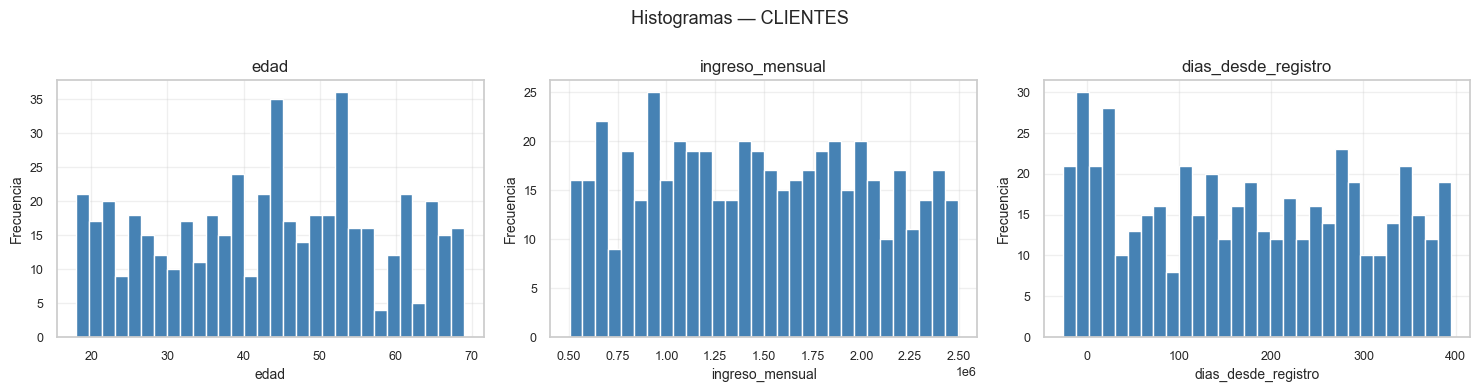

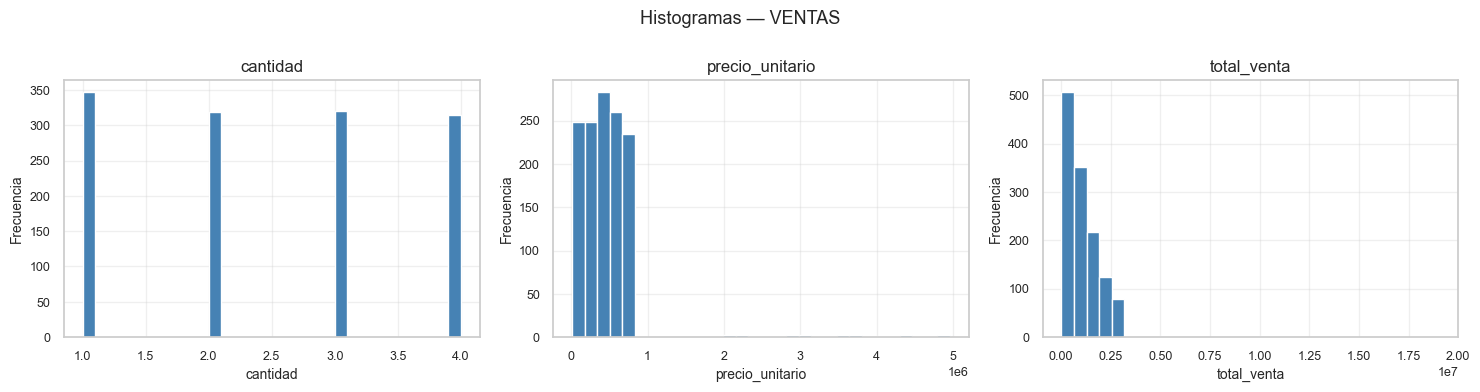

In [382]:
## Histogramas
for label, df, cols in [('CLIENTES', df_cli, cols_cli), ('VENTAS', df_ven, cols_ven)]:
    fig, axes = plt.subplots(1, len(cols), figsize=(15, 4))
    fig.suptitle(f'Histogramas — {label}', fontsize=13)
    for ax, col in zip(axes, cols):
        df[col].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

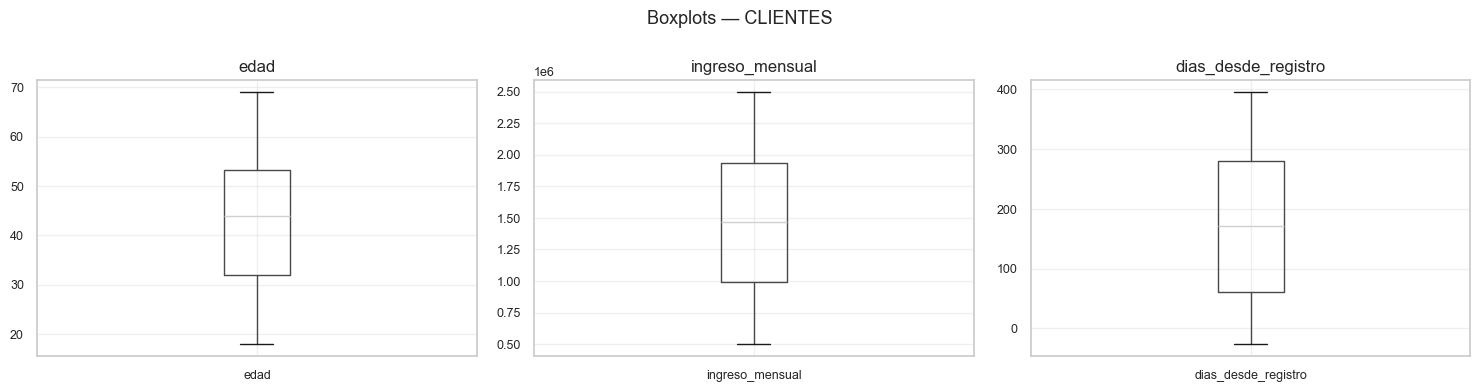

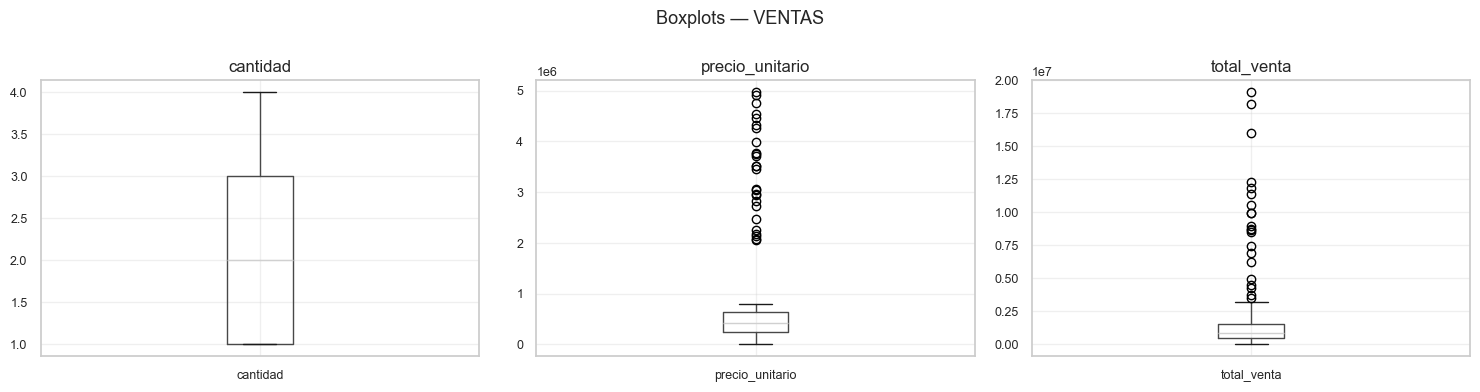

In [383]:
## Boxplots
for label, df, cols in [('CLIENTES', df_cli, cols_cli), ('VENTAS', df_ven, cols_ven)]:
    fig, axes = plt.subplots(1, len(cols), figsize=(15, 4))
    fig.suptitle(f'Boxplots — {label}', fontsize=13)
    for ax, col in zip(axes, cols):
        df[[col]].dropna().boxplot(ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

In [384]:
## Valores atipicos

for label, df, cols in [('CLIENTES', df_cli, cols_cli), ('VENTAS', df_ven, cols_ven)]:
    print(f'\n{label}')
    for col in cols:
        s = df[col].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR
        sin_atip = s[(s >= lim_inf) & (s <= lim_sup)]
        atip = len(s) - len(sin_atip)

        print(f'\n  {col}:')
        print(f'    Límite inferior:     {lim_inf:,.2f}')
        print(f'    Límite superior:     {lim_sup:,.2f}')
        print(f'    Atípicos:            {atip} ({atip/len(s)*100:.1f}%)')
        print(f'    Media  CON atípicos: {s.mean():,.2f}')
        print(f'    Media  SIN atípicos: {sin_atip.mean():,.2f}')
        print(f'    Mediana CON atípicos:{s.median():,.2f}')
        print(f'    Mediana SIN atípicos:{sin_atip.median():,.2f}')


CLIENTES

  edad:
    Límite inferior:     0.12
    Límite superior:     85.12
    Atípicos:            0 (0.0%)
    Media  CON atípicos: 43.33
    Media  SIN atípicos: 43.33
    Mediana CON atípicos:44.00
    Mediana SIN atípicos:44.00

  ingreso_mensual:
    Límite inferior:     -433,707.00
    Límite superior:     3,360,771.00
    Atípicos:            0 (0.0%)
    Media  CON atípicos: 1,470,488.98
    Media  SIN atípicos: 1,470,488.98
    Mediana CON atípicos:1,464,163.00
    Mediana SIN atípicos:1,464,163.00

  dias_desde_registro:
    Límite inferior:     -268.75
    Límite superior:     609.25
    Atípicos:            0 (0.0%)
    Media  CON atípicos: 173.52
    Media  SIN atípicos: 173.52
    Mediana CON atípicos:170.50
    Mediana SIN atípicos:170.50

VENTAS

  cantidad:
    Límite inferior:     -2.00
    Límite superior:     6.00
    Atípicos:            0 (0.0%)
    Media  CON atípicos: 2.46
    Media  SIN atípicos: 2.46
    Mediana CON atípicos:2.00
    Mediana SIN atípicos

## Lección 3 : - Correlación

### Objetivo: Detectar y cuantificar relaciones entre variables numéricas

In [385]:
df_merge = df_ven.merge(df_cli[['cliente_id','edad','ingreso_mensual']], on='cliente_id', how='left')
cols_ven  = ['cantidad', 'precio_unitario', 'total_venta']
cols_cruz = ['edad', 'ingreso_mensual', 'cantidad', 'precio_unitario', 'total_venta']

In [386]:
## Coeficiente de Person

print("PEARSON — VENTAS")
print(df_ven[cols_ven].corr().round(3))

print("\nPEARSON — CRUZADA ")
print(df_merge[cols_cruz].corr().round(3))

PEARSON — VENTAS
                 cantidad  precio_unitario  total_venta
cantidad             1.00            -0.01         0.38
precio_unitario     -0.01             1.00         0.81
total_venta          0.38             0.81         1.00

PEARSON — CRUZADA 
                 edad  ingreso_mensual  cantidad  precio_unitario  total_venta
edad             1.00             0.06     -0.03             0.01        -0.01
ingreso_mensual  0.06             1.00     -0.06             0.02        -0.02
cantidad        -0.03            -0.06      1.00            -0.01         0.38
precio_unitario  0.01             0.02     -0.01             1.00         0.81
total_venta     -0.01            -0.02      0.38             0.81         1.00


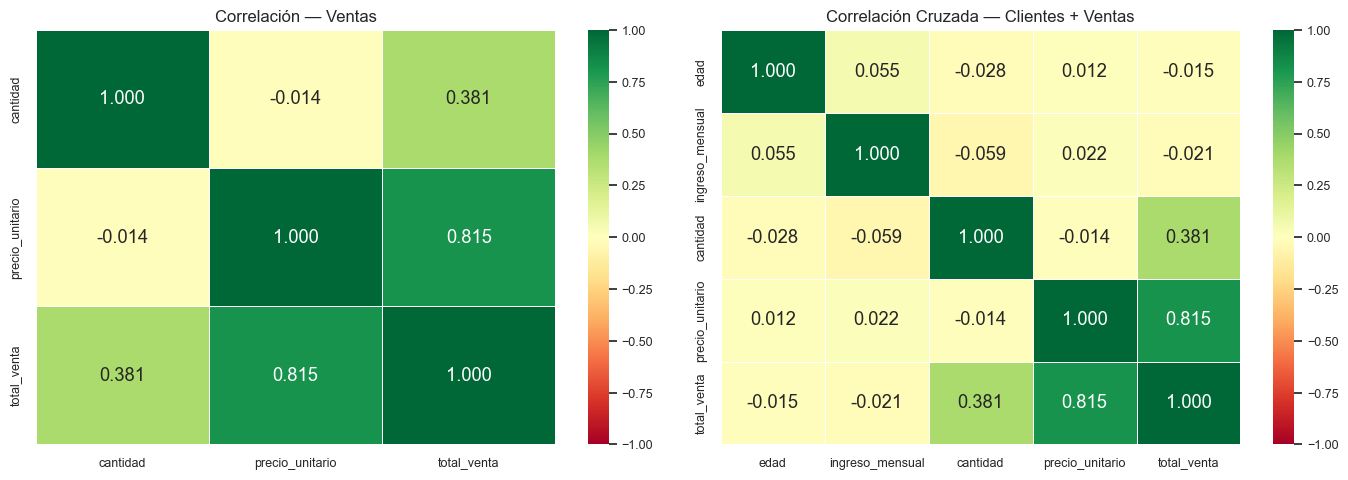

In [387]:
# Matriz de correlación (se usó Seaborn para mejor visualización)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df_ven[cols_ven].corr(), annot=True, fmt='.3f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Correlación — Ventas')

sns.heatmap(df_merge[cols_cruz].corr(), annot=True, fmt='.3f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Correlación Cruzada — Clientes + Ventas')

plt.tight_layout()
plt.show()

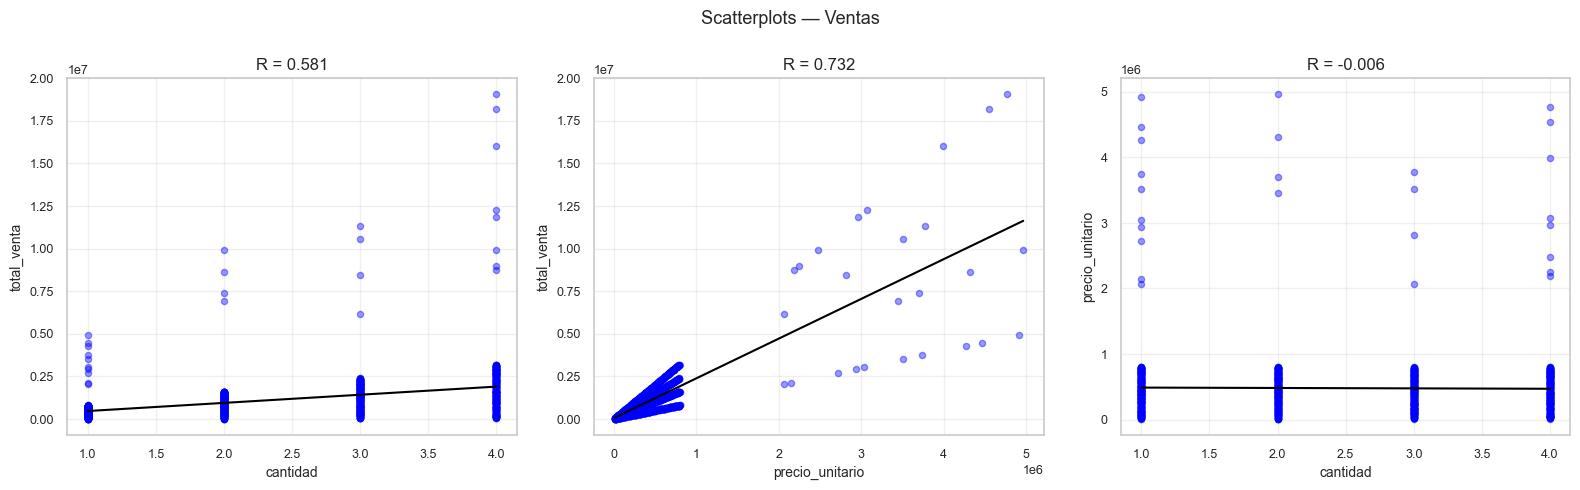

In [388]:
# Scatterplots 
pares = [
    ('cantidad',        'total_venta',   0.581),
    ('precio_unitario', 'total_venta',   0.732),
    ('cantidad',        'precio_unitario',-0.006)
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Scatterplots — Ventas', fontsize=13)

for ax, (x, y, r) in zip(axes, pares):
    ax.scatter(df_ven[x], df_ven[y], alpha=0.4, s=20, color='blue')
    m, b = np.polyfit(df_ven[x], df_ven[y], 1)
    xr = np.linspace(df_ven[x].min(), df_ven[x].max(), 100)
    ax.plot(xr, m*xr+b, color='black', linewidth=1.5)
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'R = {r}')

plt.tight_layout()
plt.show()

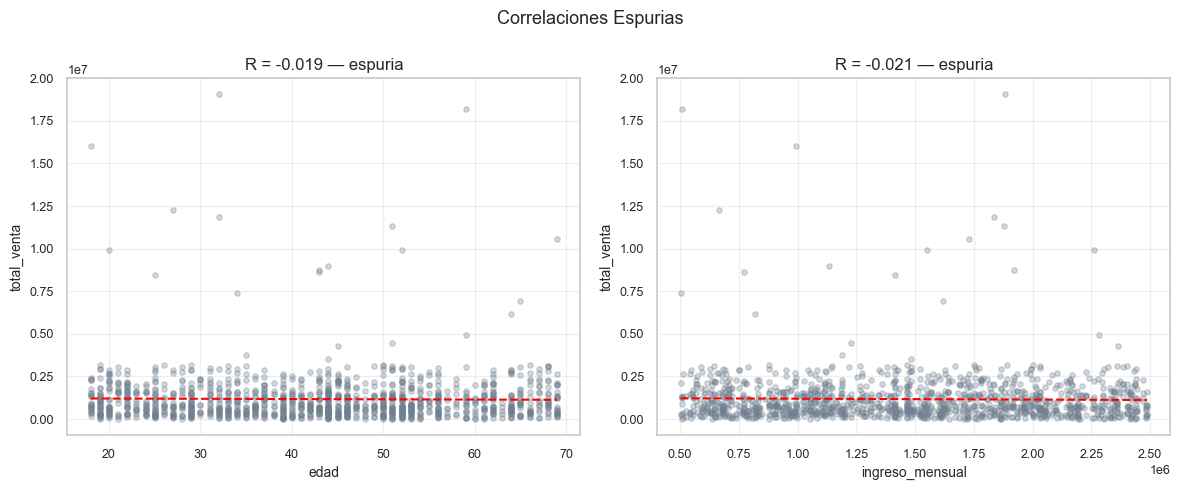

In [389]:
pares_esp = [
    ('edad',            'total_venta', -0.019),
    ('ingreso_mensual', 'total_venta', -0.021)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Correlaciones Espurias', fontsize=13)

for ax, (x, y, r) in zip(axes, pares_esp):
    ax.scatter(df_merge[x], df_merge[y], alpha=0.3, s=15, color='slategray')
    m, b = np.polyfit(df_merge[x], df_merge[y], 1)
    xr = np.linspace(df_merge[x].min(), df_merge[x].max(), 100)
    ax.plot(xr, m*xr+b, color='red', linewidth=1.5, linestyle='--')
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'R = {r} — espuria')

plt.tight_layout()
plt.show()

## Lección 4: - Regresiones lineales

### Objetivo: Implementar un modelo de regresión simple y múltiple para explicar variables dependientes.

In [390]:
# Unir clientes y ventas
df = df_ven.merge(df_cli[['cliente_id','edad','ingreso_mensual']], on='cliente_id', how='left')
y  = df['total_venta']

In [391]:
# Modelo simple
X1 = sm.add_constant(df['precio_unitario'])
modelo1 = sm.OLS(y, X1).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:            total_venta   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.664
Method:                 Least Squares   F-statistic:                     2565.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):          1.12e-309
Time:                        10:04:53   Log-Likelihood:                -19542.
No. Observations:                1300   AIC:                         3.909e+04
Df Residuals:                    1298   BIC:                         3.910e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            5.587e+04   3.16e+04     

In [392]:
# Modelo multiple 
X2 = sm.add_constant(df[['cantidad', 'precio_unitario', 'edad', 'ingreso_mensual']])
modelo2 = sm.OLS(y, X2).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:            total_venta   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     1459.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:04:53   Log-Likelihood:                -19142.
No. Observations:                1300   AIC:                         3.829e+04
Df Residuals:                    1295   BIC:                         3.832e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -1.049e+06   7.93e+04    -

In [407]:
# R², MSE, MAE
for label, modelo, X in [('Simple', modelo1, X1), ('Múltiple', modelo2, X2)]:
    pred = modelo.predict(X)
    mse  = mean_squared_error(y, pred)
    mae  = mean_absolute_error(y, pred)
    print(f"\n{label}")
    print(f"  R²:   {modelo.rsquared:.4f}")
    print(f"  MSE:  {mse:,.0f}")
    print(f"  MAE:  {mae:,.0f}")


Simple
  R²:   0.6640
  MSE:  667,380,559,744
  MAE:  490,472

Múltiple
  R²:   0.8184
  MSE:  360,675,930,828
  MAE:  269,175


In [394]:
# Significancia predictoria
print(" COEFICIENTES MODELO MÚLTIPLE \n")
resumen = pd.DataFrame({
    'Coeficiente': modelo2.params,
    'P-valor':     modelo2.pvalues,
    'Significativo': modelo2.pvalues < 0.05
})
print(resumen.round(4))

 COEFICIENTES MODELO MÚLTIPLE 

                 Coeficiente  P-valor  Significativo
const            -1048664.38     0.00           True
cantidad           490124.51     0.00           True
precio_unitario         2.35     0.00           True
edad                -1322.82     0.26          False
ingreso_mensual        -0.04     0.22          False


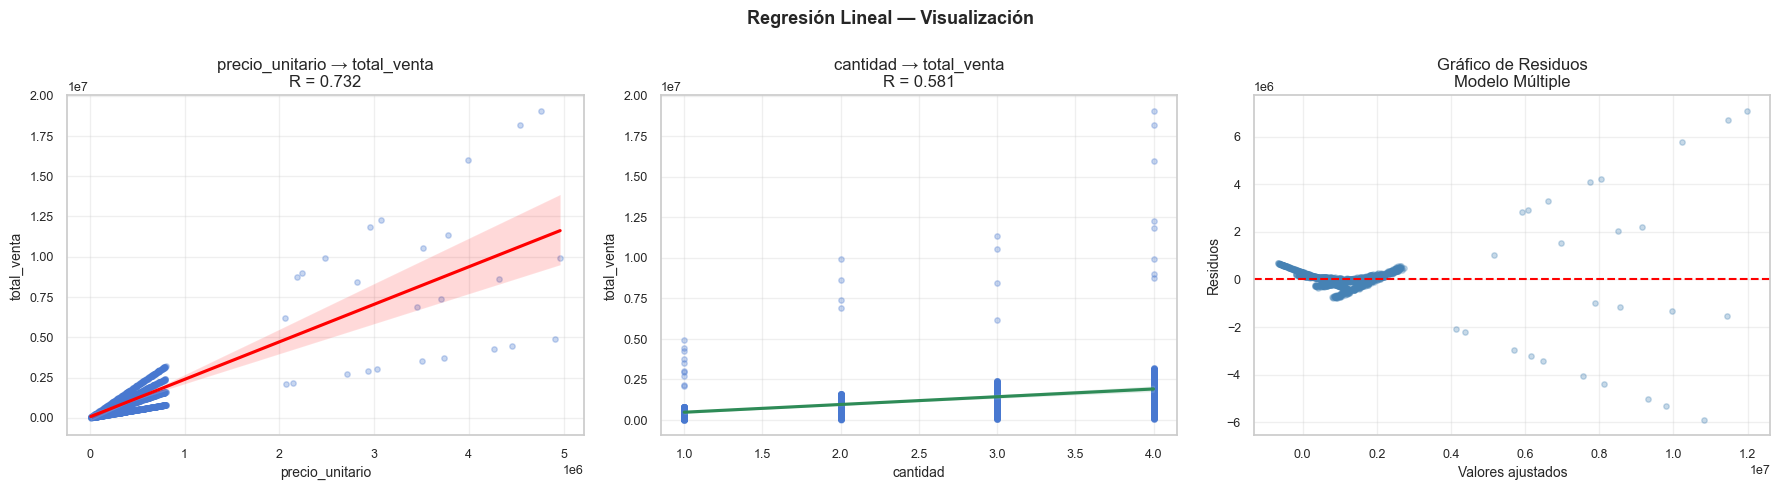

In [395]:
# Visualización Seaborn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regresión Lineal — Visualización', fontsize=13, fontweight='bold')

# Scatter + regresión: precio vs total
sns.regplot(data=df, x='precio_unitario', y='total_venta',
            scatter_kws={'alpha':0.3, 's':15}, line_kws={'color':'red'},
            ax=axes[0])
axes[0].set_title('precio_unitario → total_venta\nR = 0.732')

# Scatter + regresión: cantidad vs total
sns.regplot(data=df, x='cantidad', y='total_venta',
            scatter_kws={'alpha':0.3, 's':15}, line_kws={'color':'seagreen'},
            ax=axes[1])
axes[1].set_title('cantidad → total_venta\nR = 0.581')

# Residuos del modelo múltiple
residuos = modelo2.resid
axes[2].scatter(modelo2.fittedvalues, residuos, alpha=0.3, s=15, color='steelblue')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Valores ajustados')
axes[2].set_ylabel('Residuos')
axes[2].set_title('Gráfico de Residuos\nModelo Múltiple')

plt.tight_layout()
plt.show()

## Lección 5: - Análisis visual de datos

### Objetivo: Representar relaciones complejas y distribuciones mediante Seaborn.

In [396]:
# Unir datasets
df = df_ven.merge(df_cli[['cliente_id','edad','ingreso_mensual','region','genero','segmento_ingreso']],
                on='cliente_id', how='left')

# Estilo global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

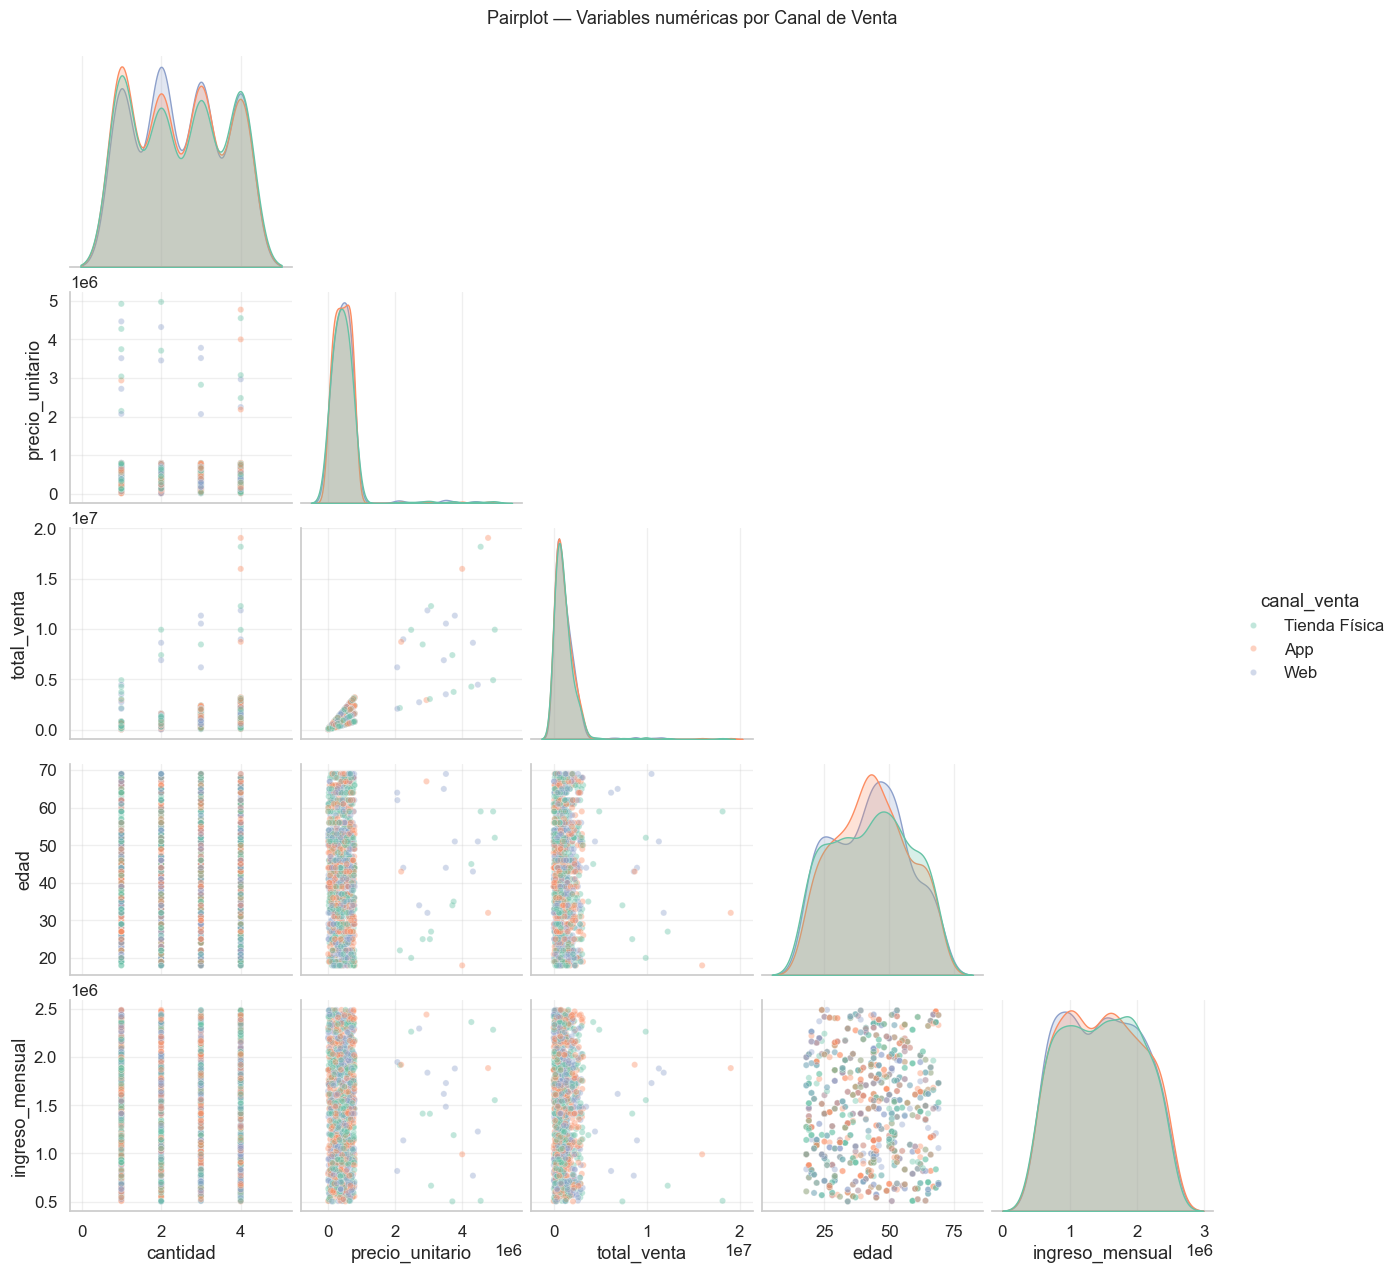

In [397]:
# Pairplot
cols_pair = ['cantidad', 'precio_unitario', 'total_venta', 'edad', 'ingreso_mensual']

g = sns.pairplot(
    df[cols_pair + ['canal_venta']],
    hue='canal_venta',
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20},
    palette='Set2',
    corner=True
)
g.fig.suptitle('Pairplot — Variables numéricas por Canal de Venta', y=1.02, fontsize=13)
plt.show()

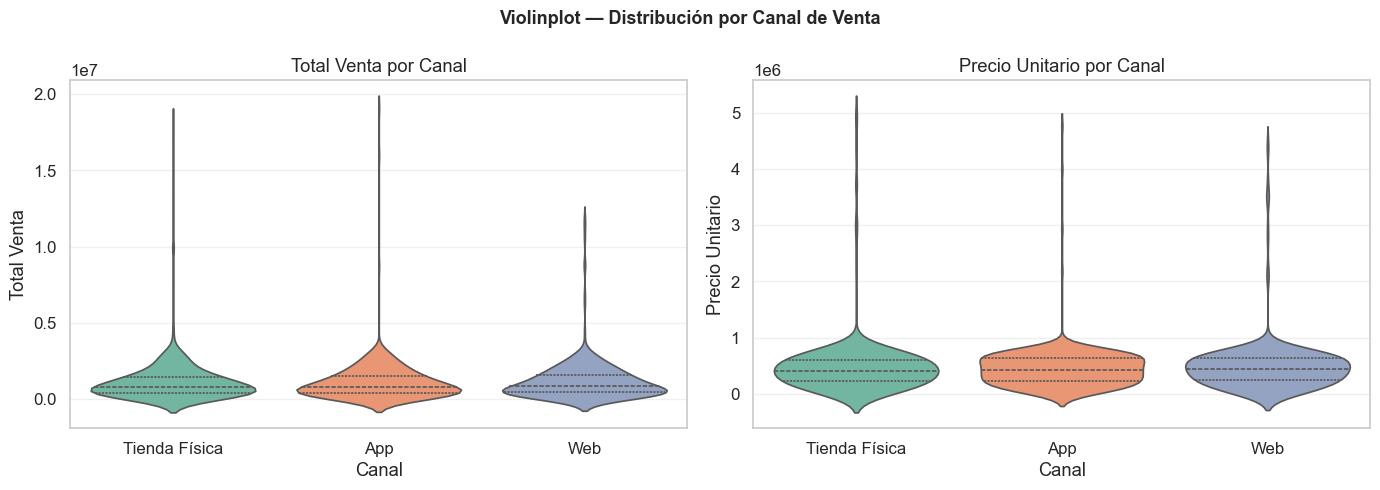

In [398]:
# Violinplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Violinplot — Distribución por Canal de Venta', fontsize=13, fontweight='bold')

sns.violinplot(data=df, x='canal_venta', y='total_venta',
            palette='Set2', inner='quartile', ax=axes[0])
axes[0].set_title('Total Venta por Canal')
axes[0].set_xlabel('Canal')
axes[0].set_ylabel('Total Venta')

sns.violinplot(data=df, x='canal_venta', y='precio_unitario',
            palette='Set2', inner='quartile', ax=axes[1])
axes[1].set_title('Precio Unitario por Canal')
axes[1].set_xlabel('Canal')
axes[1].set_ylabel('Precio Unitario')

plt.tight_layout()
plt.show()

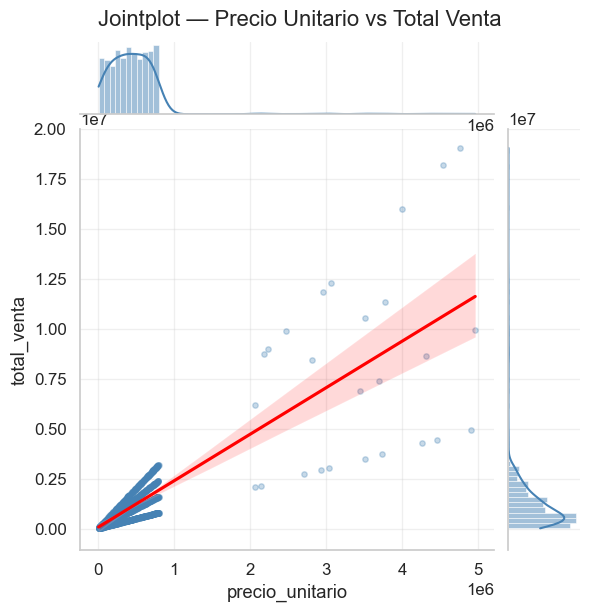

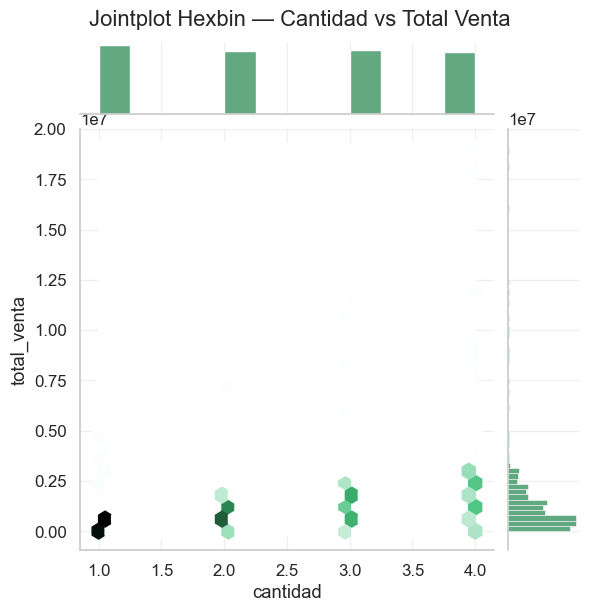

In [399]:
# Jointplot 1: precio vs total
g1 = sns.jointplot(
    data=df, x='precio_unitario', y='total_venta',
    kind='reg',
    color='steelblue',
    scatter_kws={'alpha': 0.3, 's': 15},
    line_kws={'color': 'red'}
)
g1.fig.suptitle('Jointplot — Precio Unitario vs Total Venta', y=1.02)
plt.show()

# Jointplot 2: cantidad vs total (hexbin)
g2 = sns.jointplot(
    data=df, x='cantidad', y='total_venta',
    kind='hex',
    color='seagreen'
)
g2.fig.suptitle('Jointplot Hexbin — Cantidad vs Total Venta', y=1.02)
plt.show()

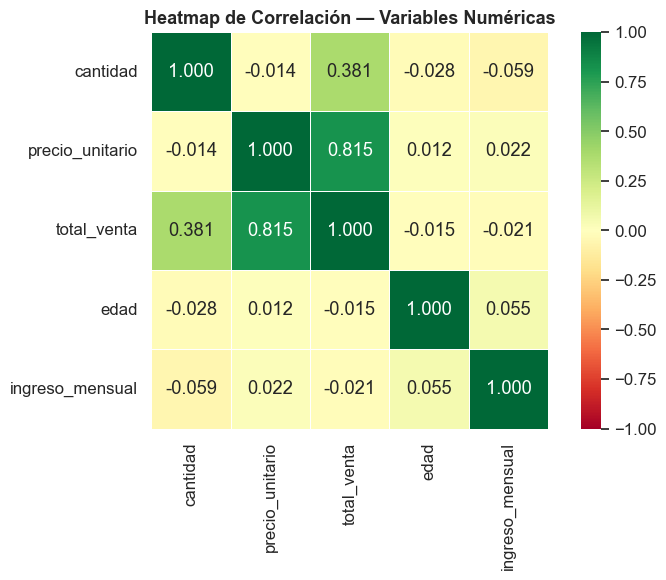

In [400]:
# Heatmap
cols_heat = ['cantidad', 'precio_unitario', 'total_venta', 'edad', 'ingreso_mensual']
corr = df[cols_heat].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)
ax.set_title('Heatmap de Correlación — Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

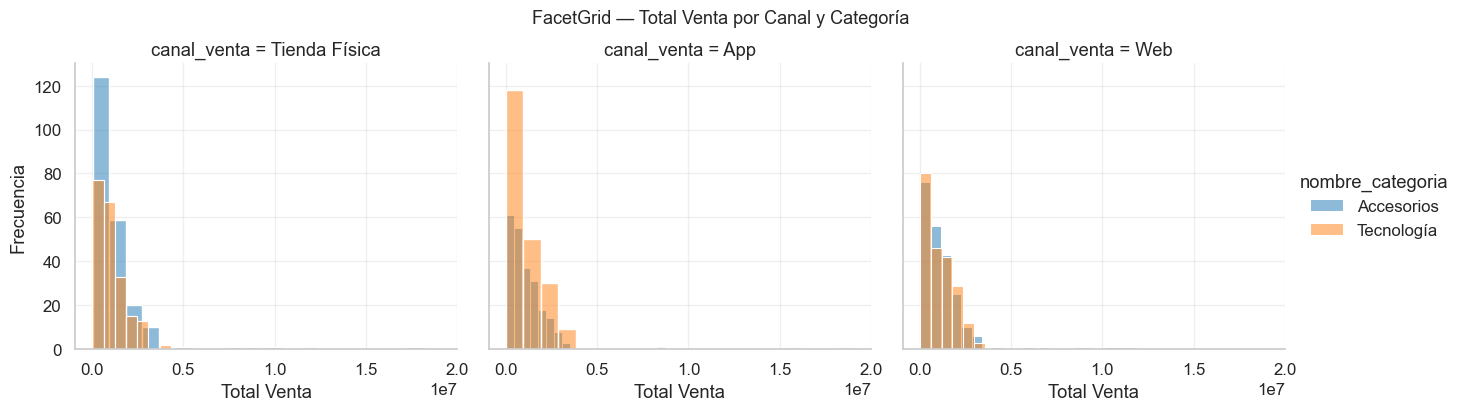

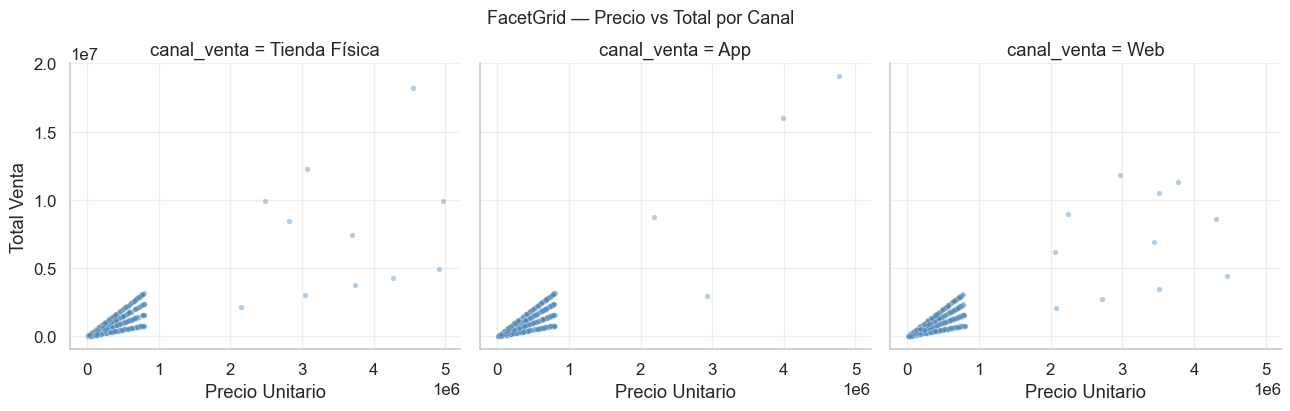

In [401]:
# FacetGrid 1: distribución total_venta por canal y categoría
g = sns.FacetGrid(df, col='canal_venta', hue='nombre_categoria',
                height=4, aspect=1.1, palette='tab10')
g.map(sns.histplot, 'total_venta', bins=20, alpha=0.5)
g.add_legend()
g.set_axis_labels('Total Venta', 'Frecuencia')
g.figure.suptitle('FacetGrid — Total Venta por Canal y Categoría', y=1.03, fontsize=13)
plt.show()

# FacetGrid 2: precio vs total segmentado por canal
g2 = sns.FacetGrid(df, col='canal_venta', height=4, aspect=1.1, palette='Set1')
g2.map_dataframe(sns.scatterplot, x='precio_unitario', y='total_venta',
                alpha=0.4, s=15, color='steelblue')
g2.set_axis_labels('Precio Unitario', 'Total Venta')
g2.figure.suptitle('FacetGrid — Precio vs Total por Canal', y=1.03, fontsize=13)
plt.show()

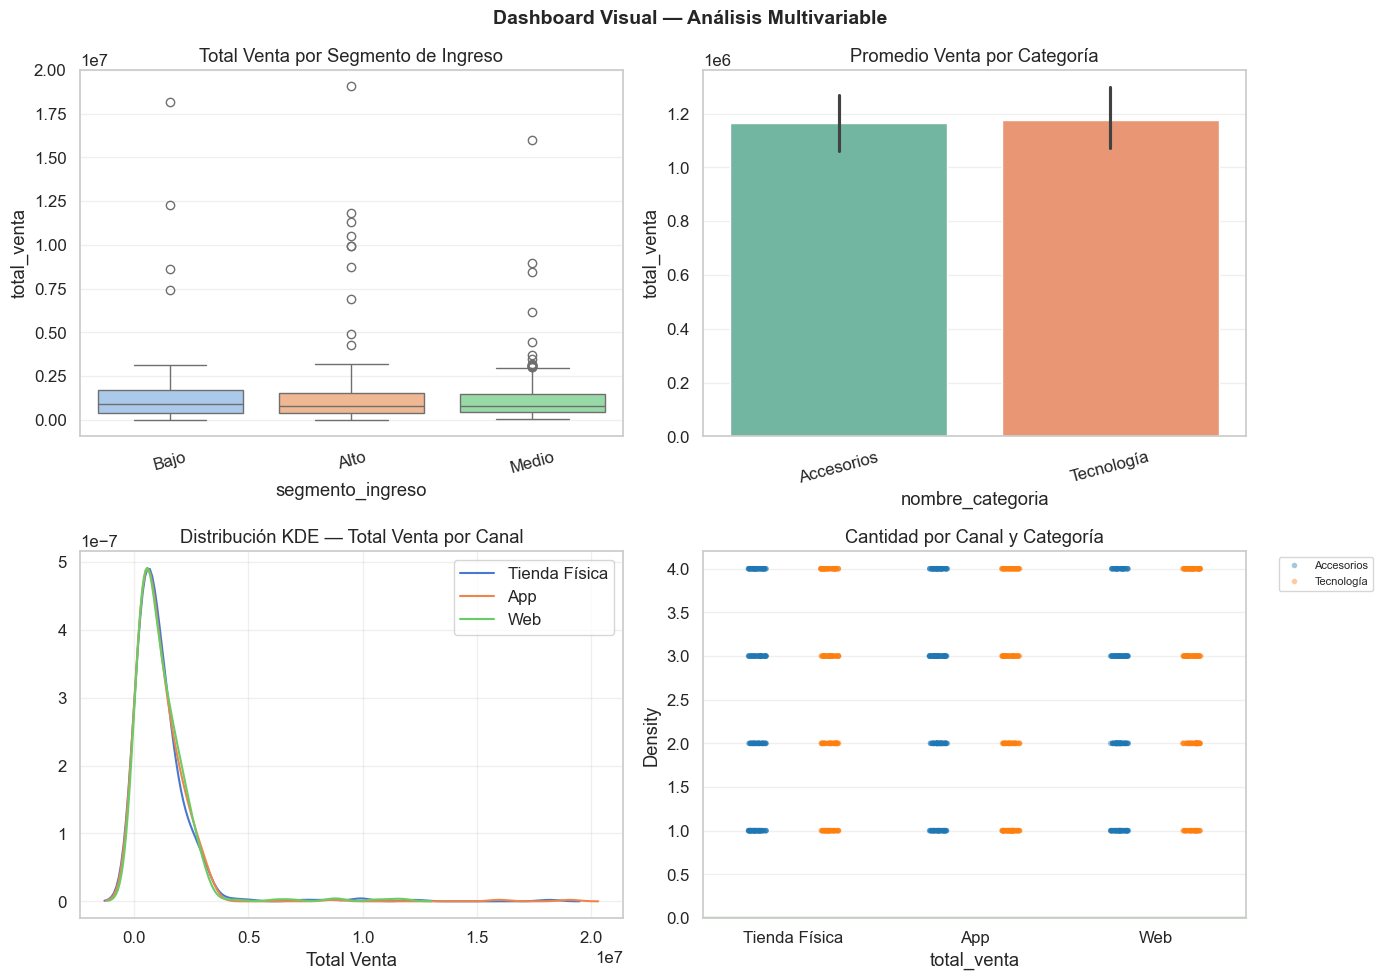

In [402]:
# Visuaizaciones multivariable combinada
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard Visual — Análisis Multivariable', fontsize=14, fontweight='bold')

# Boxplot por segmento de ingreso
sns.boxplot(data=df, x='segmento_ingreso', y='total_venta',
            palette='pastel', ax=axes[0,0])
axes[0,0].set_title('Total Venta por Segmento de Ingreso')
axes[0,0].tick_params(axis='x', rotation=15)

# Barplot promedio por categoría
sns.barplot(data=df, x='nombre_categoria', y='total_venta',
            estimator='mean', palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Promedio Venta por Categoría')
axes[0,1].tick_params(axis='x', rotation=15)

# KDE total_venta por canal
for canal in df['canal_venta'].unique():
    subset = df[df['canal_venta'] == canal]['total_venta']
    axes[1,0].plot(*sns.kdeplot(subset).get_lines()[-1].get_data(), label=canal)
axes[1,0].set_title('Distribución KDE — Total Venta por Canal')
axes[1,0].set_xlabel('Total Venta')
axes[1,0].legend()

# Stripplot cantidad por canal
sns.stripplot(data=df, x='canal_venta', y='cantidad',
            hue='nombre_categoria', dodge=True,
            alpha=0.4, size=4, palette='tab10', ax=axes[1,1])
axes[1,1].set_title('Cantidad por Canal y Categoría')
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## Lección 6: - Librería Marplotlib

### Objetivo: Crear visualizaciones personalizadas y exportables.

In [403]:
# Estilo global
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.family':       'sans-serif',
    'axes.titlesize':    12,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
})

# Unir datasets
df = df_ven.merge(
    df_cli[['cliente_id','edad','ingreso_mensual','region','genero','segmento_ingreso']],
    on='cliente_id', how='left'
)

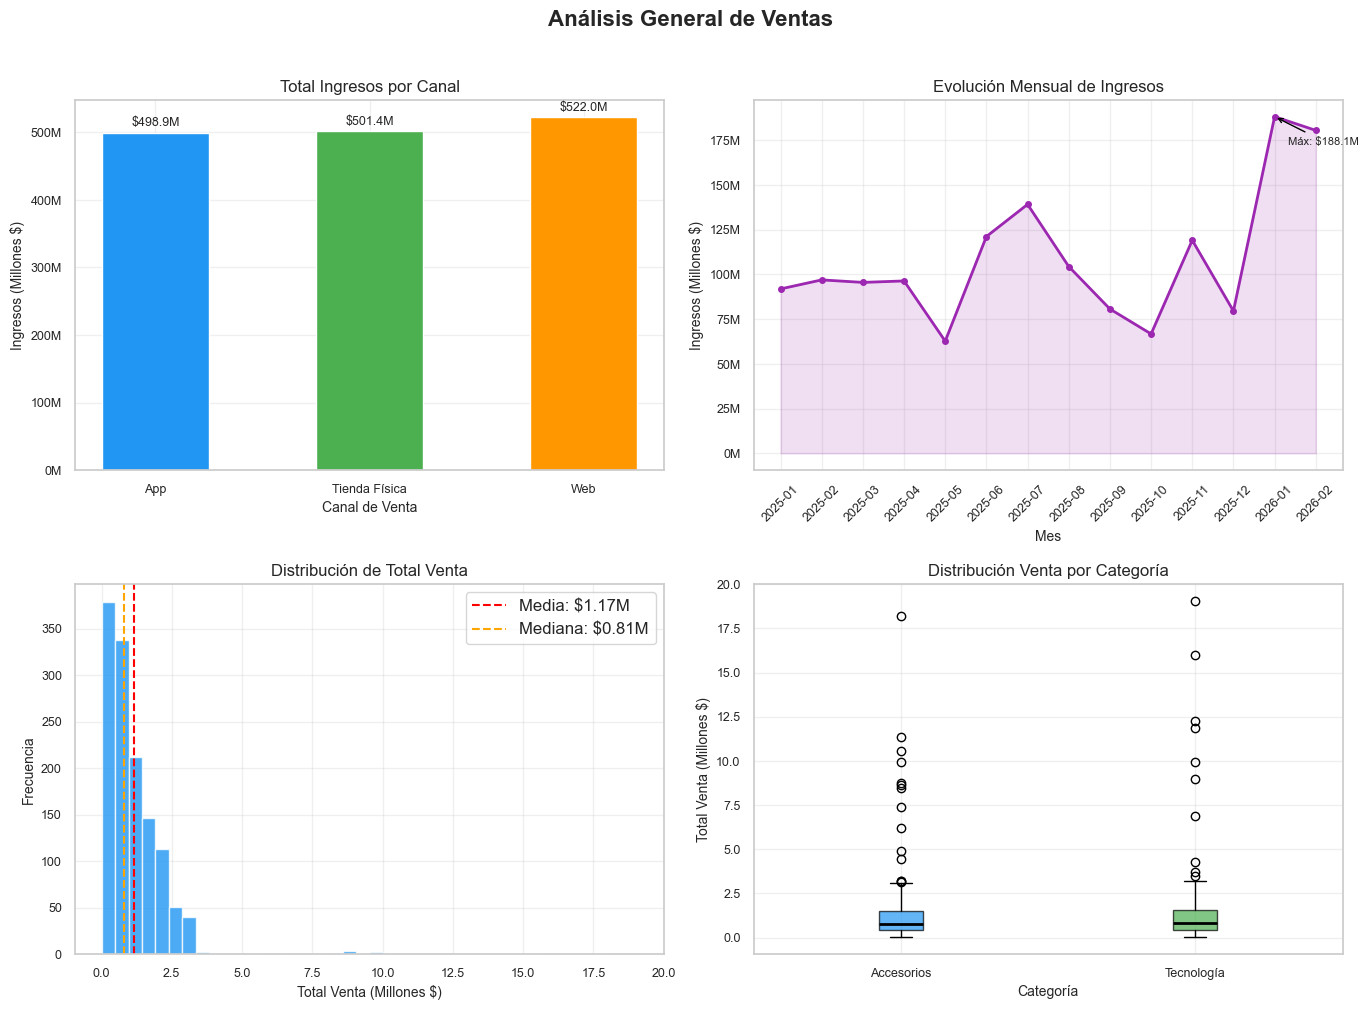

Guardado: grafico_general.png


In [404]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis General de Ventas', fontsize=16, fontweight='bold', y=1.01)

# ── Gráfico 1: Barras por canal ──
ventas_canal = df.groupby('canal_venta')['total_venta'].sum() / 1e6
colores = ['#2196F3', '#4CAF50', '#FF9800']
bars = axes[0,0].bar(ventas_canal.index, ventas_canal.values, color=colores, edgecolor='white', width=0.5)
axes[0,0].set_title('Total Ingresos por Canal')
axes[0,0].set_xlabel('Canal de Venta')
axes[0,0].set_ylabel('Ingresos (Millones $)')
axes[0,0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fM'))
for bar, val in zip(bars, ventas_canal.values):
    axes[0,0].annotate(f'${val:.1f}M', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 5), textcoords='offset points', ha='center', fontsize=9)

# ── Gráfico 2: Serie temporal mensual ──
df['periodo'] = df['fecha_venta'].dt.to_period('M').astype(str)
serie = df.groupby('periodo')['total_venta'].sum() / 1e6
axes[0,1].plot(serie.index, serie.values, color='#9C27B0', linewidth=2, marker='o', markersize=4)
axes[0,1].fill_between(serie.index, serie.values, alpha=0.15, color='#9C27B0')
axes[0,1].set_title('Evolución Mensual de Ingresos')
axes[0,1].set_xlabel('Mes')
axes[0,1].set_ylabel('Ingresos (Millones $)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fM'))
# Anotación del máximo
idx_max = serie.idxmax()
axes[0,1].annotate(f'Máx: ${serie[idx_max]:.1f}M',
                xy=(idx_max, serie[idx_max]),
                xytext=(10, -20), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='black'), fontsize=8)

# ── Gráfico 3: Histograma total_venta ──
axes[1,0].hist(df['total_venta'] / 1e6, bins=40, color='#2196F3',
            edgecolor='white', alpha=0.8)
axes[1,0].axvline(df['total_venta'].mean() / 1e6, color='red',
                linestyle='--', linewidth=1.5, label=f"Media: ${df['total_venta'].mean()/1e6:.2f}M")
axes[1,0].axvline(df['total_venta'].median() / 1e6, color='orange',
                linestyle='--', linewidth=1.5, label=f"Mediana: ${df['total_venta'].median()/1e6:.2f}M")
axes[1,0].set_title('Distribución de Total Venta')
axes[1,0].set_xlabel('Total Venta (Millones $)')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].legend()

# ── Gráfico 4: Boxplot por categoría ──
categorias = df['nombre_categoria'].unique()
data_box = [df[df['nombre_categoria'] == c]['total_venta'].values / 1e6 for c in categorias]
bp = axes[1,1].boxplot(data_box, labels=categorias, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#2196F3', '#4CAF50']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1,1].set_title('Distribución Venta por Categoría')
axes[1,1].set_xlabel('Categoría')
axes[1,1].set_ylabel('Total Venta (Millones $)')

plt.tight_layout()
plt.savefig('grafico_general.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: grafico_general.png")

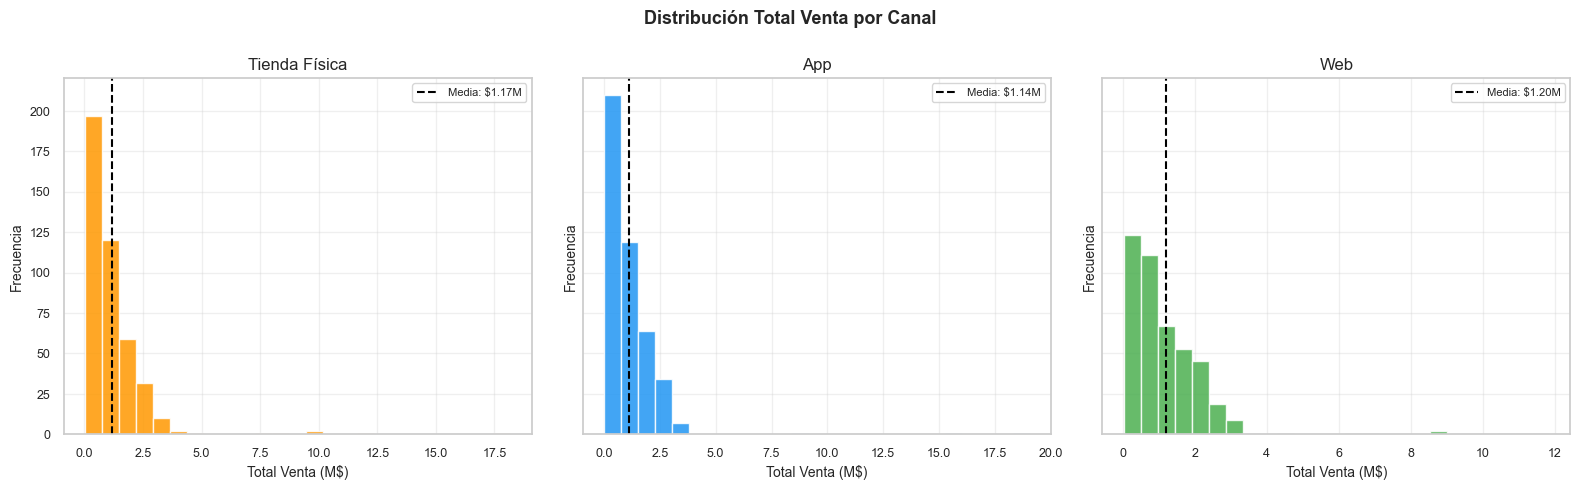

In [405]:
canales = df['canal_venta'].unique()
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Distribución Total Venta por Canal', fontsize=13, fontweight='bold')

colores_canal = {'App': '#2196F3', 'Web': '#4CAF50', 'Tienda Física': '#FF9800'}

for ax, canal in zip(axes, canales):
    datos = df[df['canal_venta'] == canal]['total_venta'] / 1e6
    ax.hist(datos, bins=25, color=colores_canal.get(canal, 'gray'),
            edgecolor='white', alpha=0.85)
    ax.axvline(datos.mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Media: ${datos.mean():.2f}M')
    ax.set_title(canal)
    ax.set_xlabel('Total Venta (M$)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('facet_canales.png', dpi=150, bbox_inches='tight')
plt.show()


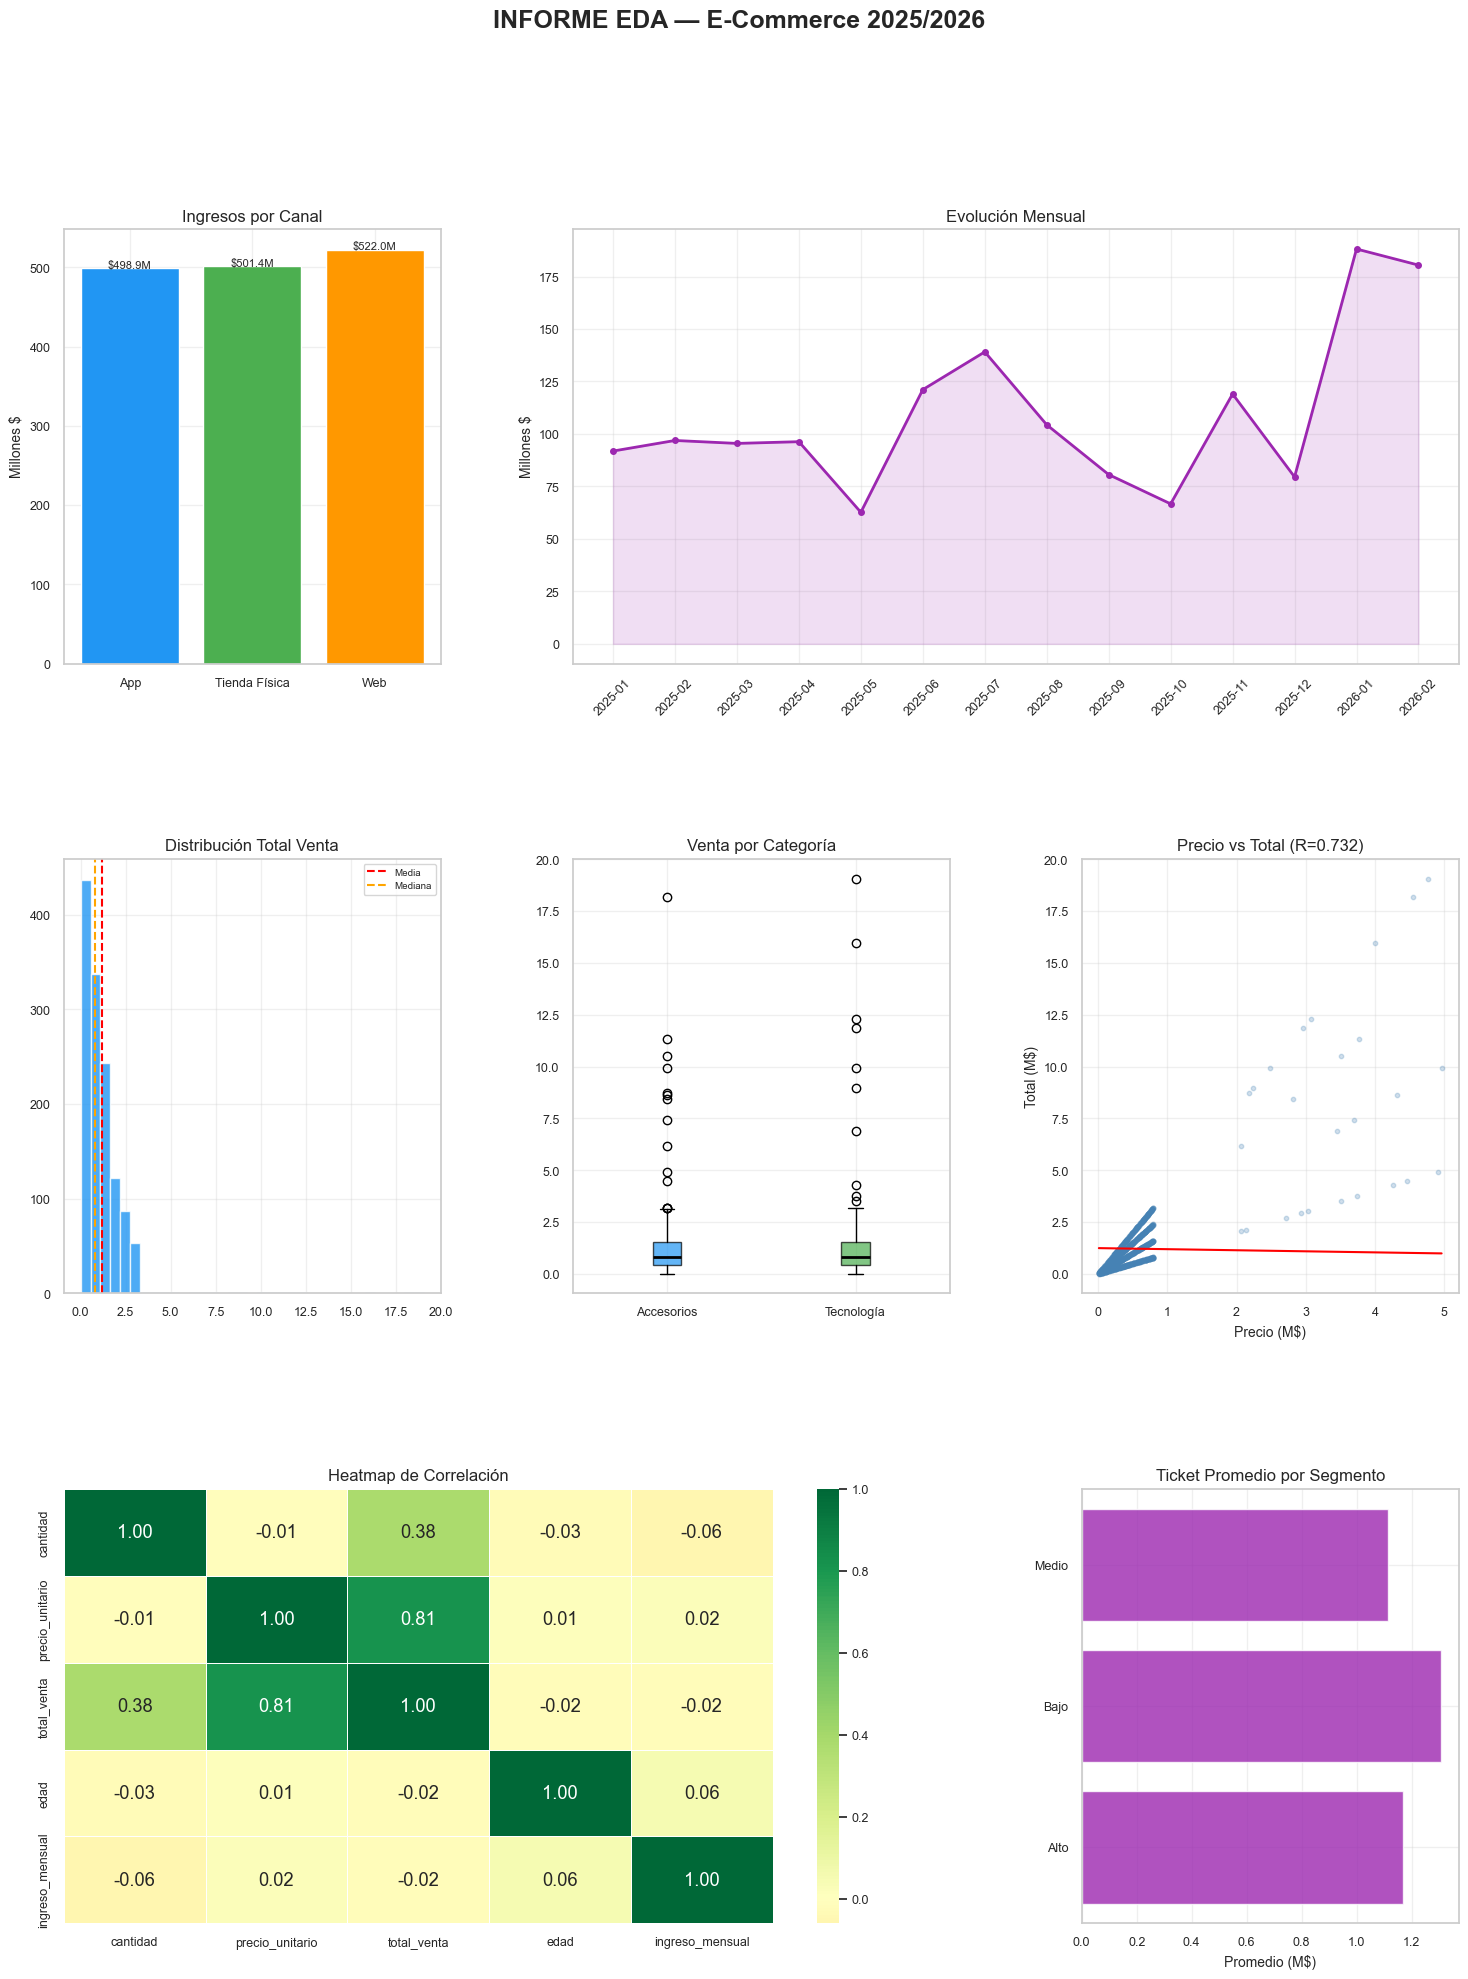

✅ Guardado: informe_EDA_final.png


In [406]:
fig = plt.figure(figsize=(18, 22))
fig.patch.set_facecolor('white')
fig.suptitle('INFORME EDA — E-Commerce 2025/2026',
            fontsize=18, fontweight='bold', y=0.98)

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ── Panel 1: Ingresos por canal ──
ax1 = fig.add_subplot(gs[0, 0])
ventas_canal = df.groupby('canal_venta')['total_venta'].sum() / 1e6
bars = ax1.bar(ventas_canal.index, ventas_canal.values,
            color=['#2196F3','#4CAF50','#FF9800'], edgecolor='white')
ax1.set_title('Ingresos por Canal')
ax1.set_ylabel('Millones $')
for bar, val in zip(bars, ventas_canal.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${val:.1f}M', ha='center', fontsize=8)

# ── Panel 2: Evolución mensual ──
ax2 = fig.add_subplot(gs[0, 1:])
serie = df.groupby('periodo')['total_venta'].sum() / 1e6
ax2.plot(serie.index, serie.values, color='#9C27B0', linewidth=2, marker='o', markersize=4)
ax2.fill_between(serie.index, serie.values, alpha=0.15, color='#9C27B0')
ax2.set_title('Evolución Mensual')
ax2.set_ylabel('Millones $')
ax2.tick_params(axis='x', rotation=45)

# ── Panel 3: Histograma ──
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(df['total_venta']/1e6, bins=35, color='#2196F3', edgecolor='white', alpha=0.8)
ax3.axvline(df['total_venta'].mean()/1e6, color='red', linestyle='--', linewidth=1.5, label='Media')
ax3.axvline(df['total_venta'].median()/1e6, color='orange', linestyle='--', linewidth=1.5, label='Mediana')
ax3.set_title('Distribución Total Venta')
ax3.legend(fontsize=7)

# ── Panel 4: Boxplot categoría ──
ax4 = fig.add_subplot(gs[1, 1])
data_box = [df[df['nombre_categoria']==c]['total_venta'].values/1e6 for c in categorias]
bp = ax4.boxplot(data_box, labels=categorias, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#2196F3','#4CAF50']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax4.set_title('Venta por Categoría')

# ── Panel 5: Scatter precio vs total ──
ax5 = fig.add_subplot(gs[1, 2])
ax5.scatter(df['precio_unitario']/1e6, df['total_venta']/1e6,
            alpha=0.25, s=10, color='steelblue')
xr = np.linspace(df['precio_unitario'].min(), df['precio_unitario'].max(), 100)
ax5.plot(xr/1e6, (m*xr+b)/1e6, color='red', linewidth=1.5)
ax5.set_title('Precio vs Total (R=0.732)')
ax5.set_xlabel('Precio (M$)')
ax5.set_ylabel('Total (M$)')

# ── Panel 6: Heatmap correlación ──
ax6 = fig.add_subplot(gs[2, :2])
cols_h = ['cantidad','precio_unitario','total_venta','edad','ingreso_mensual']
sns.heatmap(df[cols_h].corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax6)
ax6.set_title('Heatmap de Correlación')

# ── Panel 7: Barras por segmento ──
ax7 = fig.add_subplot(gs[2, 2])
seg = df.groupby('segmento_ingreso')['total_venta'].mean() / 1e6
ax7.barh(seg.index, seg.values, color='#9C27B0', edgecolor='white', alpha=0.8)
ax7.set_title('Ticket Promedio por Segmento')
ax7.set_xlabel('Promedio (M$)')

plt.savefig('informe_EDA_final.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Guardado: informe_EDA_final.png")